In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 75
==================================================

Week: 11 of 24
Day: 75 of 168
Date: Friday, January 24, 2026
Topic: PPO (Proximal Policy Optimization)

Week 11 Progress:
✅ Day 71: Policy Gradients & REINFORCE
✅ Day 72: REINFORCE Training & Optimization
✅ Day 73: Actor-Critic (A2C/A3C)
✅ Day 74: A2C Training & Analysis
🔄 Day 75: PPO (Proximal Policy Optimization) (TODAY!)
⬜ Day 76: PPO Training & Optimization
⬜ Day 77: Algorithm Comparison & Week Completion

Progress: 71.4% (5/7 days)

==================================================
🎯 Week 11: Policy Gradient Methods & Advanced RL

Day 71-74 Recap:
✅ REINFORCE algorithm (Monte Carlo PG)
✅ Actor-Critic (A2C) with value baseline
✅ CartPole & LunarLander training
✅ Variance reduction validated
✅ Sample efficiency improvements

Day 75 Focus:
🆕 PPO algorithm (state-of-the-art!)
🆕 Trust region optimization
🆕 Clipped surrogate objective
🆕 Multiple epochs of updates
🆕 Industry-standard approach

==================================================
🎯 Today's Learning Objectives:

1. PPO Fundamentals
   - Why PPO was needed
   - Trust region problem
   - Clipped surrogate objective
   - PPO vs A2C improvements

2. Mathematical Framework
   - Importance sampling
   - Policy ratio r(θ)
   - Clipping mechanism
   - Conservative policy updates

3. PPO Algorithm
   - Multiple update epochs
   - Mini-batch training
   - GAE (Generalized Advantage Estimation)
   - Complete implementation

4. CartPole Implementation
   - PPO agent from scratch
   - Training and evaluation
   - Compare with A2C
   - Validate improvements

📚 Today's Structure:
Part 1 (2h): PPO Theory & Motivation
Part 2 (2h): Mathematical Framework
Part 3 (2h): PPO Implementation
Part 4 (2h): CartPole Training & Comparison

Total Time: ~8 hours

🎯 SUCCESS CRITERIA:
✅ Understand PPO algorithm completely
✅ Implement PPO from scratch
✅ Train on CartPole (>475 avg)
✅ Compare with A2C
✅ Document improvements
✅ Ready for Day 76 (LunarLander)

💡 The Big Idea:

The Policy Gradient Problem:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REINFORCE & A2C Issue:
  • Single gradient step per batch
  • Can't reuse data efficiently
  • Large updates can destroy policy
  • Unstable training

PPO Solution:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Multiple gradient steps per batch
  • Clip updates to stay close to old policy
  • Trust region constraint (implicit)
  • More stable, more sample efficient
  • Current SOTA for many tasks!

PPO vs A2C:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
A2C:
  • Single update per batch
  • Can waste data
  • No constraint on policy change
  • Good but not optimal

PPO:
  • Multiple updates per batch
  • Reuses data efficiently
  • Clips large policy changes
  • More stable and efficient
  • Industry standard! 🏆

Key Innovation:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Clipped Surrogate Objective:
  L^CLIP(θ) = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]

Where:
  r(θ) = π_new(a|s) / π_old(a|s)  (policy ratio)
  ε = 0.2 (clip range)
  
This simple trick makes all the difference! 🎯

Algorithm Evolution:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REINFORCE → A2C → PPO

Each step reduces variance and improves stability:
✓ REINFORCE: Basic policy gradient
✓ A2C: Add value baseline
✓ PPO: Add trust region constraint

PPO is the culmination of policy gradient research! 🚀

Real-World Impact:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PPO is used in:
- OpenAI's ChatGPT (RLHF training)
- Game AI (Dota 2, StarCraft)
- Robotics control
- Autonomous vehicles
- Most modern RL applications

Learning PPO = Learning industry-standard RL! 💪

==================================================
"""

In [1]:
# ==================================================
# IMPORT LIBRARIES & SETUP
# ==================================================

print("=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
import time
import os
from datetime import datetime
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Gymnasium
import gymnasium as gym

print("✅ Libraries imported!")

# Set random seeds
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Matplotlib settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# Create directories
os.makedirs('results/ppo', exist_ok=True)
os.makedirs('results/comparisons', exist_ok=True)
os.makedirs('results/models', exist_ok=True)

print("\n✅ Setup complete!")
print("=" * 80)
print("\n🎯 Ready for Day 75 - PPO!")
print("=" * 80)

📚 IMPORTING LIBRARIES
✅ Libraries imported!

🖥️  Device: cpu

✅ Setup complete!

🎯 Ready for Day 75 - PPO!


In [2]:
print("\n" + "=" * 80)
print("🎯 PART 1: PPO THEORY & MOTIVATION")
print("=" * 80)


🎯 PART 1: PPO THEORY & MOTIVATION



EXERCISE 1.1: Understanding Why PPO Was Needed

📊 Visualizing The Problem:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1967345560.py:260: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1967345560.py:260: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1967345560.py:260: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1967345560.py:260: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1967345560.py:260: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1967345560.py:261: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savef

✅ Motivation visualization saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) miss

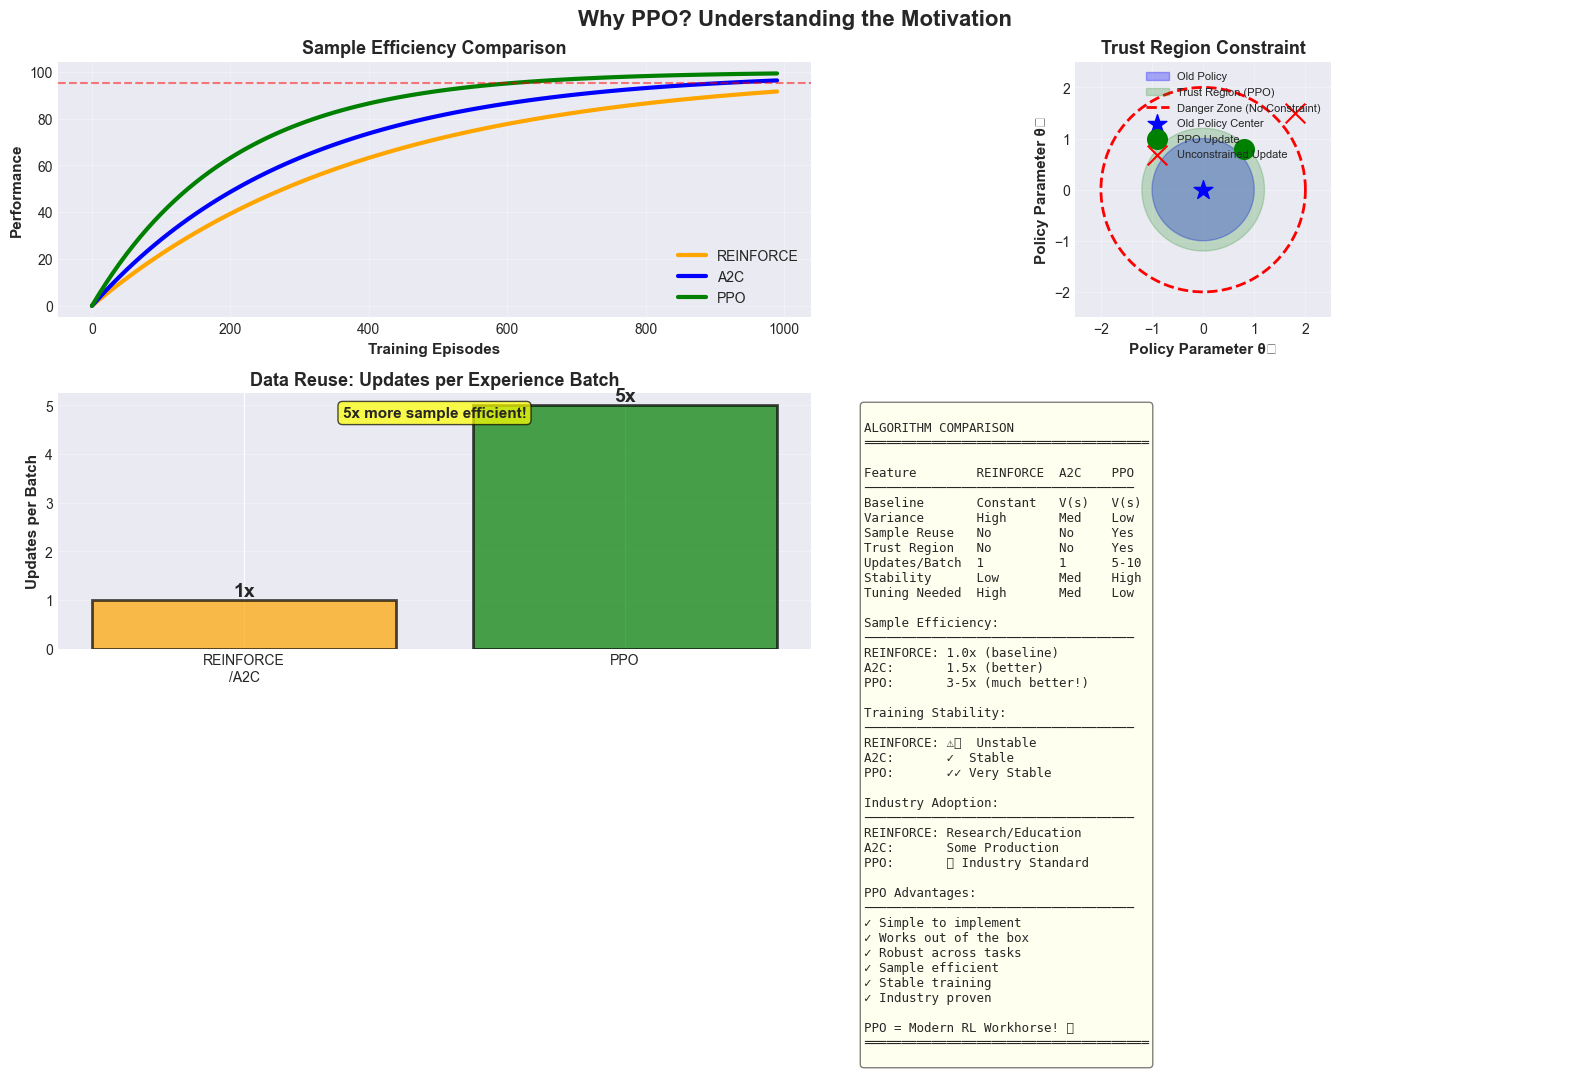


💡 Key Takeaways:

1. PROBLEM: Previous methods waste data
   • REINFORCE/A2C: 1 update per batch
   • Throw away experience after single use
   • Sample inefficient

2. SOLUTION: PPO enables data reuse
   • Multiple updates per batch (5-10 epochs)
   • 3-5x more sample efficient
   • Trust region keeps it safe

3. KEY INNOVATION: Clipped objective
   • Simple to implement
   • Prevents policy collapse
   • Much more stable

4. RESULT: Industry standard
   • Used in ChatGPT, game AI, robotics
   • Robust across many tasks
   • Less hyperparameter tuning needed

Next: Deep dive into the math! 🎯


✅ Exercise 1.1 Complete!


In [3]:
# ==================================================
# EXERCISE 1.1: WHY PPO? THE MOTIVATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.1: Understanding Why PPO Was Needed")
print("=" * 80)

"""
📖 THEORY: The Problem with Previous Methods

REINFORCE & A2C Limitations:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Sample Inefficiency:
   • Collect batch of experience
   • Single gradient update
   • Throw away data
   • Need new samples for next update
   
   This is WASTEFUL! We could do better.

2. Policy Collapse:
   • No constraint on policy change
   • Single large update can destroy policy
   • Policy becomes deterministic or nonsensical
   • Hard to recover from bad updates
   
   Example: Policy suddenly outputs only one action forever!

3. Unstable Training:
   • Performance varies wildly
   • Hard to tune hyperparameters
   • Sensitive to learning rate
   • Often fails to converge

THE CORE PROBLEM: Sample Efficiency vs Stability
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

On-Policy Methods (REINFORCE, A2C):
  Pros: Stable (use fresh data)
  Cons: Sample inefficient (throw away data)

Off-Policy Methods (DQN):
  Pros: Sample efficient (replay buffer)
  Cons: Only for value-based methods

Question: Can we get best of both worlds?
Answer: YES! That's PPO! 🎯

PPO'S INNOVATION: Trust Region Optimization
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Key Insight:
  We can reuse data for multiple updates IF we constrain
  how much the policy can change!

Trust Region Idea:
  • Keep new policy close to old policy
  • Limit the size of policy updates
  • Safe to do multiple gradient steps
  • More stable, more sample efficient!

How to Enforce Trust Region?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Option 1: TRPO (Trust Region Policy Optimization)
  • Hard constraint using KL divergence
  • Mathematically complex
  • Expensive to compute (2nd order optimization)
  • Works great but impractical

Option 2: PPO (Proximal Policy Optimization)
  • Soft constraint using clipping
  • Simple to implement
  • First order optimization only
  • Works almost as well as TRPO
  • Much more practical!

PPO = Simplified TRPO with similar performance! 🎯

WHAT PPO ENABLES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Multiple Epochs:
   • Update policy 3-10 times per batch
   • Reuse same data
   • More sample efficient

2. Conservative Updates:
   • Clip prevents large policy changes
   • No policy collapse
   • More stable training

3. Robust Performance:
   • Works across many environments
   • Less hyperparameter tuning
   • Industry standard for good reason!

The Evolution:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REINFORCE (1992):
  • Basic policy gradient
  • High variance
  • Sample inefficient

A2C (2017):
  • Add value baseline
  • Lower variance
  • Still sample inefficient

PPO (2017):
  • Add trust region
  • Multiple epochs
  • Sample efficient + stable
  • Current SOTA! 🏆

PPO is the culmination of 25+ years of policy gradient research!
"""

print("\n📊 Visualizing The Problem:")
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Why PPO? Understanding the Motivation', fontsize=16, fontweight='bold')

# 1. Sample Efficiency Comparison
ax1 = axes[0, 0]

# Simulate learning curves
episodes = np.arange(0, 1000, 10)
reinforce_perf = 100 * (1 - np.exp(-episodes/400))  # Slow learning
a2c_perf = 100 * (1 - np.exp(-episodes/300))       # Faster
ppo_perf = 100 * (1 - np.exp(-episodes/200))       # Fastest

ax1.plot(episodes, reinforce_perf, linewidth=3, label='REINFORCE', color='orange')
ax1.plot(episodes, a2c_perf, linewidth=3, label='A2C', color='blue')
ax1.plot(episodes, ppo_perf, linewidth=3, label='PPO', color='green')

ax1.set_xlabel('Training Episodes', fontsize=11, fontweight='bold')
ax1.set_ylabel('Performance', fontsize=11, fontweight='bold')
ax1.set_title('Sample Efficiency Comparison', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(95, color='red', linestyle='--', alpha=0.5, label='Target')

# 2. Policy Update Constraint
ax2 = axes[0, 1]

# Visualize trust region
theta = np.linspace(0, 2*np.pi, 100)
r_old = 1.0

# Old policy region
ax2.fill(r_old * np.cos(theta), r_old * np.sin(theta), 
        alpha=0.3, color='blue', label='Old Policy')

# Trust region (PPO allows)
r_trust = 1.2
ax2.fill(r_trust * np.cos(theta), r_trust * np.sin(theta), 
        alpha=0.2, color='green', label='Trust Region (PPO)')

# Danger zone (unconstrained could go here)
r_danger = 2.0
ax2.plot(r_danger * np.cos(theta), r_danger * np.sin(theta), 
        'r--', linewidth=2, label='Danger Zone (No Constraint)')

ax2.scatter([0], [0], s=200, c='blue', marker='*', zorder=5, label='Old Policy Center')
ax2.scatter([0.8], [0.8], s=200, c='green', marker='o', zorder=5, label='PPO Update')
ax2.scatter([1.8], [1.5], s=200, c='red', marker='x', zorder=5, label='Unconstrained Update')

ax2.set_xlabel('Policy Parameter θ₁', fontsize=11, fontweight='bold')
ax2.set_ylabel('Policy Parameter θ₂', fontsize=11, fontweight='bold')
ax2.set_title('Trust Region Constraint', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)
ax2.set_aspect('equal')

# 3. Data Reuse
ax3 = axes[1, 0]

methods = ['REINFORCE\n/A2C', 'PPO']
updates_per_batch = [1, 5]  # PPO does ~5 epochs
colors = ['orange', 'green']

bars = ax3.bar(methods, updates_per_batch, color=colors, alpha=0.7, 
              edgecolor='black', linewidth=2)
ax3.set_ylabel('Updates per Batch', fontsize=11, fontweight='bold')
ax3.set_title('Data Reuse: Updates per Experience Batch', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for bar, updates in zip(bars, updates_per_batch):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{updates}x', ha='center', va='bottom', 
            fontweight='bold', fontsize=14)

ax3.text(0.5, 0.95, '5x more sample efficient!',
        transform=ax3.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        fontsize=11, fontweight='bold')

# 4. Algorithm Comparison Table
ax4 = axes[1, 1]
ax4.axis('off')

comparison_text = """
ALGORITHM COMPARISON
══════════════════════════════════════

Feature        REINFORCE  A2C    PPO
────────────────────────────────────
Baseline       Constant   V(s)   V(s)
Variance       High       Med    Low
Sample Reuse   No         No     Yes
Trust Region   No         No     Yes
Updates/Batch  1          1      5-10
Stability      Low        Med    High
Tuning Needed  High       Med    Low

Sample Efficiency:
────────────────────────────────────
REINFORCE: 1.0x (baseline)
A2C:       1.5x (better)
PPO:       3-5x (much better!)

Training Stability:
────────────────────────────────────
REINFORCE: ⚠️  Unstable
A2C:       ✓  Stable
PPO:       ✓✓ Very Stable

Industry Adoption:
────────────────────────────────────
REINFORCE: Research/Education
A2C:       Some Production
PPO:       🏆 Industry Standard

PPO Advantages:
────────────────────────────────────
✓ Simple to implement
✓ Works out of the box
✓ Robust across tasks
✓ Sample efficient
✓ Stable training
✓ Industry proven

PPO = Modern RL Workhorse! 🚀
══════════════════════════════════════
"""

ax4.text(0.05, 0.95, comparison_text, transform=ax4.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/ppo_motivation.png', dpi=300, bbox_inches='tight')
print("✅ Motivation visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. PROBLEM: Previous methods waste data
   • REINFORCE/A2C: 1 update per batch
   • Throw away experience after single use
   • Sample inefficient

2. SOLUTION: PPO enables data reuse
   • Multiple updates per batch (5-10 epochs)
   • 3-5x more sample efficient
   • Trust region keeps it safe

3. KEY INNOVATION: Clipped objective
   • Simple to implement
   • Prevents policy collapse
   • Much more stable

4. RESULT: Industry standard
   • Used in ChatGPT, game AI, robotics
   • Robust across many tasks
   • Less hyperparameter tuning needed

Next: Deep dive into the math! 🎯
""")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.2: Trust Region Optimization Explained

📊 Visualizing Trust Region:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\2614803577.py:287: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\2614803577.py:288: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/trust_region.png', dpi=300, bbox_inches='tight')


✅ Trust region visualization saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


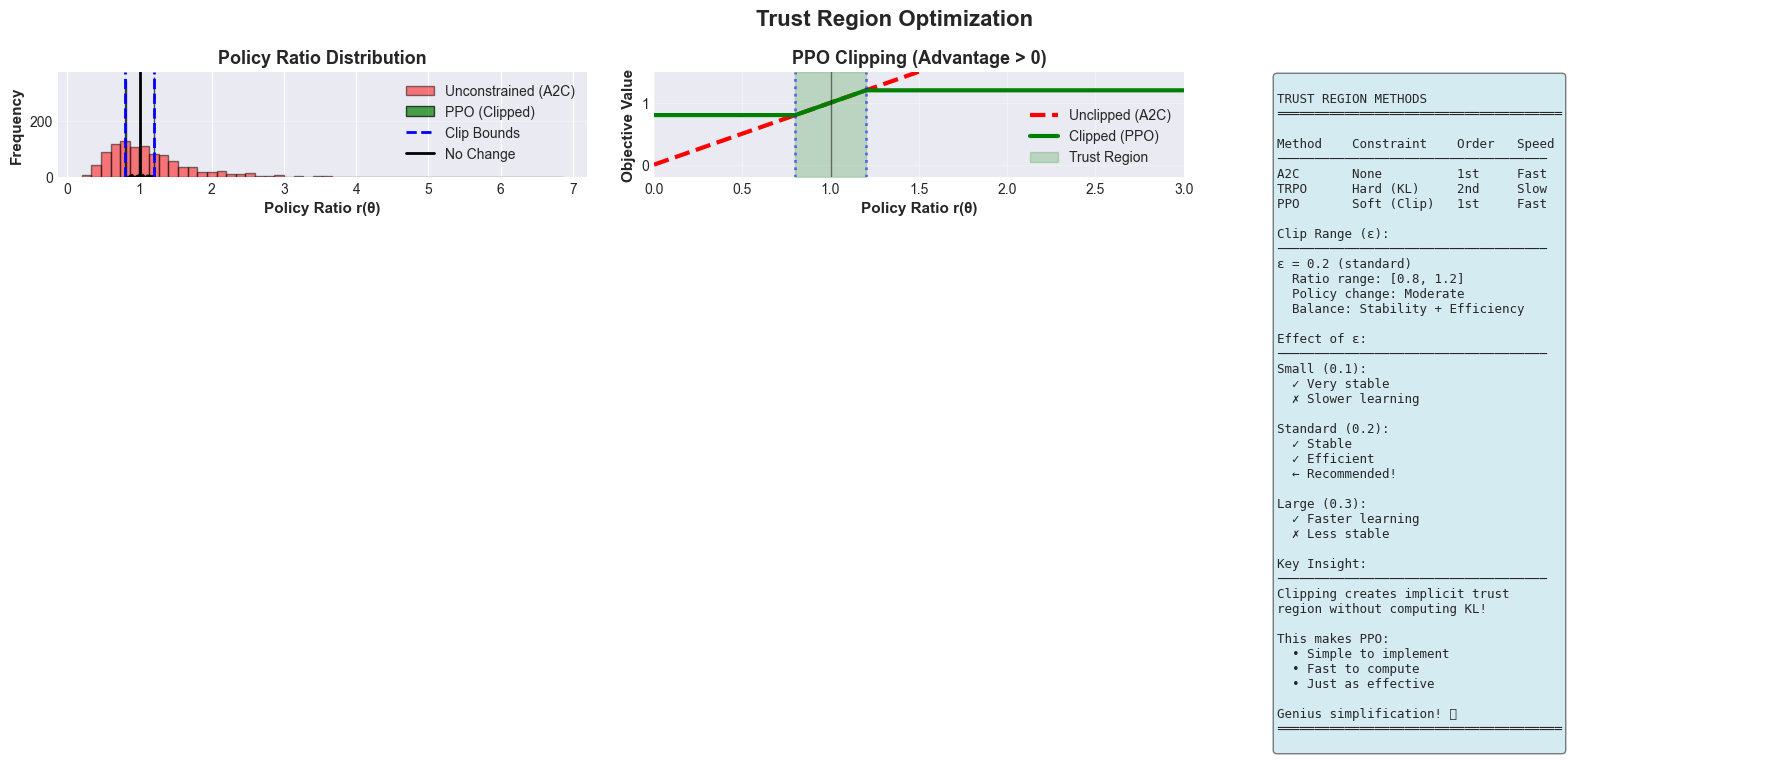


💡 Key Takeaways:

1. TRUST REGION = Limit policy change
   • Keep new policy close to old
   • Prevents policy collapse
   • Enables multiple updates

2. TWO APPROACHES:
   • TRPO: Hard constraint (complex)
   • PPO: Soft constraint (simple)

3. PPO CLIPPING:
   • Clip ratio to [1-ε, 1+ε]
   • Standard: ε = 0.2
   • Implicitly creates trust region

4. WHY IT WORKS:
   • Bounds gradient magnitude
   • Safe to reuse data
   • More sample efficient
   • More stable training

Next: The complete PPO algorithm! 🚀


✅ Exercise 1.2 Complete!


In [4]:
# ==================================================
# EXERCISE 1.2: TRUST REGION OPTIMIZATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.2: Trust Region Optimization Explained")
print("=" * 80)

"""
📖 THEORY: Trust Region Methods

THE FUNDAMENTAL PROBLEM:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In policy gradient methods, we want to maximize:
  J(θ) = E[R|π_θ]

Standard gradient ascent:
  θ_new = θ_old + α ∇J(θ)

Problem: No guarantee the new policy is better!
  • Could take too large a step
  • Policy might collapse
  • Performance could decrease

TRUST REGION CONSTRAINT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Idea: Limit how much the policy can change

Formally, we want:
  maximize J(θ)
  subject to: D_KL(π_old || π_new) ≤ δ

Where:
  D_KL = KL divergence (measures policy difference)
  δ = trust region size (e.g., 0.01)

This ensures the new policy isn't too different from the old!

MEASURING POLICY DIFFERENCE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KL Divergence:
  D_KL(π_old || π_new) = E[log(π_old(a|s)) - log(π_new(a|s))]

Intuition:
  • Measures "distance" between two probability distributions
  • D_KL = 0: policies are identical
  • D_KL > 0: policies are different
  • Larger D_KL = more different

Trust Region means: Keep D_KL small!

TWO APPROACHES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TRPO (Hard Constraint):
  • Explicitly enforces D_KL ≤ δ
  • Uses natural gradient (2nd order optimization)
  • Mathematically elegant
  • Complex to implement
  • Computationally expensive

PPO (Soft Constraint):
  • Implicitly enforces trust region via clipping
  • Uses regular gradient (1st order optimization)
  • Simpler to implement
  • Much faster to compute
  • Achieves similar results!

PPO's Genius: Achieve trust region without computing KL! 🎯

HOW CLIPPING CREATES TRUST REGION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Policy Ratio:
  r(θ) = π_new(a|s) / π_old(a|s)

What this means:
  r(θ) = 1.0: Policies assign same probability to action
  r(θ) > 1.0: New policy MORE likely to take action
  r(θ) < 1.0: New policy LESS likely to take action

PPO clips r(θ) to [1-ε, 1+ε]:
  • Typical: ε = 0.2
  • Range: [0.8, 1.2]
  • Prevents large policy changes!

Example:
  Old policy: π_old(a|s) = 0.5
  
  Unclipped update might give:
    π_new(a|s) = 0.9  →  r = 1.8  (too large!)
  
  PPO clips to:
    r_clip = 1.2  →  π_new ≈ 0.6  (moderate change)

This implicitly creates a trust region! 🎯

WHY THIS WORKS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Prevents Policy Collapse:
   • Can't change too much in one update
   • Maintains exploration
   • Recoverable from bad updates

2. Enables Multiple Epochs:
   • Safe to reuse data
   • Policy won't diverge too far
   • More sample efficient

3. More Stable:
   • Gradients are bounded
   • Less sensitive to learning rate
   • Robust across tasks

TRUST REGION SIZE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Clip range ε controls trust region:

ε = 0.1 (small):
  • Very conservative updates
  • Super stable
  • Slower learning
  • Use for critical applications

ε = 0.2 (standard):
  • Good balance
  • Stable and efficient
  • Default choice
  • Works for most tasks

ε = 0.3 (large):
  • More aggressive updates
  • Faster learning
  • Less stable
  • Use if confident

Standard: ε = 0.2 works great! 🎯

COMPARISON:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

No Trust Region (A2C):
  θ_new = θ_old + α ∇J(θ)
  
  • No constraint
  • Can change arbitrarily
  • Risk of collapse

TRPO (Explicit):
  maximize J(θ)
  s.t. D_KL(π_old || π_new) ≤ δ
  
  • Hard constraint
  • 2nd order optimization
  • Complex, expensive

PPO (Implicit):
  maximize E[min(r(θ)A, clip(r(θ))A)]
  
  • Soft constraint via clipping
  • 1st order optimization
  • Simple, efficient

PPO = Best of both worlds! 🏆
"""

print("\n📊 Visualizing Trust Region:")
print("=" * 80)

# Create trust region visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trust Region Optimization', fontsize=16, fontweight='bold')

# 1. Policy Ratio Distribution
ax1 = axes[0]

# Simulate policy ratios
np.random.seed(42)
ratios_no_clip = np.random.lognormal(0, 0.5, 1000)  # Unbounded
ratios_ppo = np.clip(ratios_no_clip, 0.8, 1.2)     # Clipped

ax1.hist(ratios_no_clip, bins=50, alpha=0.5, color='red', 
        edgecolor='black', label='Unconstrained (A2C)')
ax1.hist(ratios_ppo, bins=50, alpha=0.7, color='green',
        edgecolor='black', label='PPO (Clipped)')

ax1.axvline(0.8, color='blue', linestyle='--', linewidth=2, label='Clip Bounds')
ax1.axvline(1.2, color='blue', linestyle='--', linewidth=2)
ax1.axvline(1.0, color='black', linestyle='-', linewidth=2, label='No Change')

ax1.set_xlabel('Policy Ratio r(θ)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Policy Ratio Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Clipping Function
ax2 = axes[1]

r = np.linspace(0, 3, 300)
epsilon = 0.2
advantage_pos = 1.0  # Positive advantage

# Unclipped
objective_unclipped = r * advantage_pos

# Clipped
r_clipped = np.clip(r, 1-epsilon, 1+epsilon)
objective_clipped = r_clipped * advantage_pos

ax2.plot(r, objective_unclipped, linewidth=3, label='Unclipped (A2C)', color='red', linestyle='--')
ax2.plot(r, objective_clipped, linewidth=3, label='Clipped (PPO)', color='green')

ax2.axvline(0.8, color='blue', linestyle=':', linewidth=2, alpha=0.5)
ax2.axvline(1.2, color='blue', linestyle=':', linewidth=2, alpha=0.5)
ax2.axvline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax2.fill_between([0.8, 1.2], -0.2, 1.5, alpha=0.2, color='green', label='Trust Region')

ax2.set_xlabel('Policy Ratio r(θ)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Objective Value', fontsize=11, fontweight='bold')
ax2.set_title('PPO Clipping (Advantage > 0)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 3)
ax2.set_ylim(-0.2, 1.5)

# 3. Trust Region Comparison
ax3 = axes[2]
ax3.axis('off')

trust_region_text = """
TRUST REGION METHODS
══════════════════════════════════════

Method    Constraint    Order   Speed
────────────────────────────────────
A2C       None          1st     Fast
TRPO      Hard (KL)     2nd     Slow
PPO       Soft (Clip)   1st     Fast

Clip Range (ε):
────────────────────────────────────
ε = 0.2 (standard)
  Ratio range: [0.8, 1.2]
  Policy change: Moderate
  Balance: Stability + Efficiency

Effect of ε:
────────────────────────────────────
Small (0.1):
  ✓ Very stable
  ✗ Slower learning

Standard (0.2):
  ✓ Stable
  ✓ Efficient
  ← Recommended!

Large (0.3):
  ✓ Faster learning
  ✗ Less stable

Key Insight:
────────────────────────────────────
Clipping creates implicit trust
region without computing KL!

This makes PPO:
  • Simple to implement
  • Fast to compute
  • Just as effective

Genius simplification! 🎯
══════════════════════════════════════
"""

ax3.text(0.05, 0.95, trust_region_text, transform=ax3.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/trust_region.png', dpi=300, bbox_inches='tight')
print("✅ Trust region visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. TRUST REGION = Limit policy change
   • Keep new policy close to old
   • Prevents policy collapse
   • Enables multiple updates

2. TWO APPROACHES:
   • TRPO: Hard constraint (complex)
   • PPO: Soft constraint (simple)

3. PPO CLIPPING:
   • Clip ratio to [1-ε, 1+ε]
   • Standard: ε = 0.2
   • Implicitly creates trust region

4. WHY IT WORKS:
   • Bounds gradient magnitude
   • Safe to reuse data
   • More sample efficient
   • More stable training

Next: The complete PPO algorithm! 🚀
""")

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


EXERCISE 1.3: PPO's Clipped Surrogate Objective

📊 Visualizing Clipped Objective:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1020933784.py:333: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1020933784.py:334: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/clipped_objective.png', dpi=300, bbox_inches='tight')


✅ Clipped objective visualization saved!


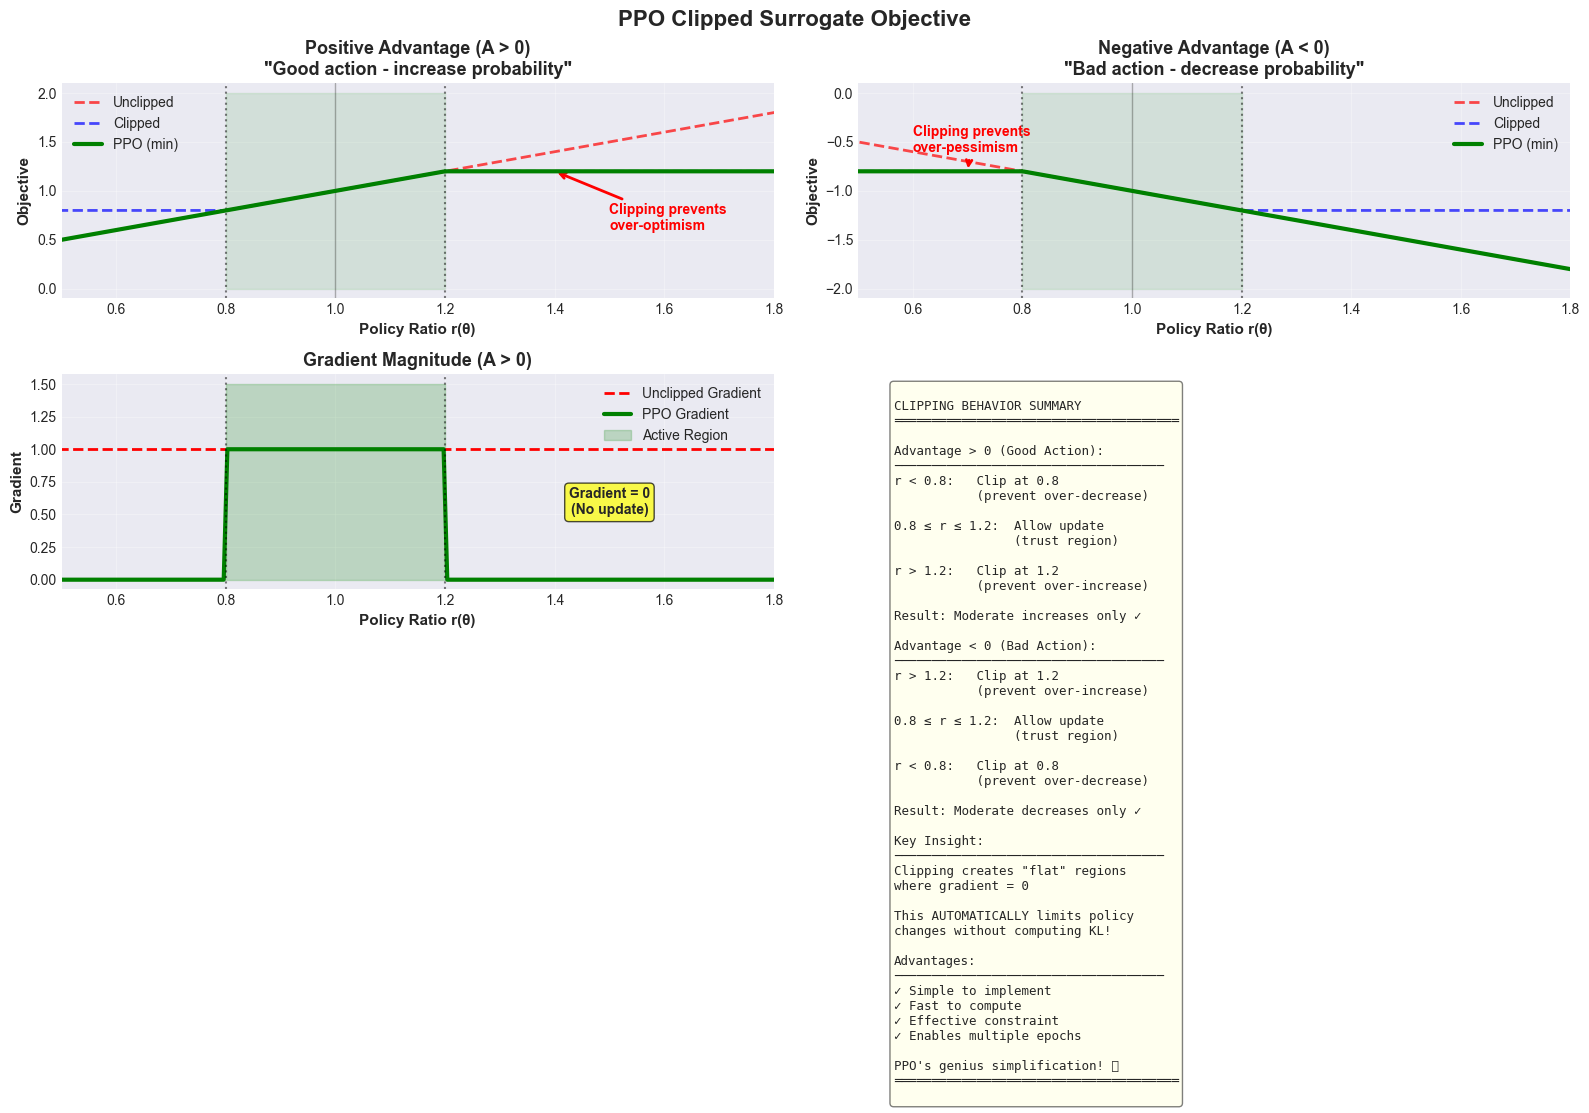


💡 Key Takeaways:

1. CLIPPED OBJECTIVE:
   L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]

   Simple but powerful formula!

2. HOW IT WORKS:
   • Compute ratio r = π_new/π_old
   • Clip to [0.8, 1.2]
   • Take minimum with unclipped
   • Creates conservative bound

3. EFFECT:
   • Prevents large policy changes
   • Gradient becomes zero outside trust region
   • Safe to do multiple updates
   • More sample efficient

4. WHY MIN?
   • Pessimistic bound
   • Only improve when safe
   • Ignore risky improvements
   • Key to stability

This is PPO's core innovation! 🏆


✅ Exercise 1.3 Complete!


In [6]:
# ==================================================
# EXERCISE 1.3: CLIPPED SURROGATE OBJECTIVE
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.3: PPO's Clipped Surrogate Objective")
print("=" * 80)

"""
📖 THEORY: The Clipped Surrogate Objective

THE STANDARD POLICY GRADIENT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regular Policy Gradient (REINFORCE, A2C):
  L^PG(θ) = E[log π(a|s) A(s,a)]

Problem: Can take arbitrarily large steps!

IMPORTANCE SAMPLING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

To reuse old data with new policy:

Policy ratio:
  r(θ) = π_new(a|s) / π_old(a|s)

Importance sampling objective:
  L^IS(θ) = E[r(θ) A(s,a)]

This allows updating with old data, but still unbounded!

PPO'S CLIPPED OBJECTIVE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The magic formula:

  L^CLIP(θ) = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]

Where:
  r(θ) = π_new(a|s) / π_old(a|s)
  ε = 0.2 (clip parameter)
  A = advantage
  
Breaking it down:

1. Compute policy ratio: r(θ)
2. Compute two objectives:
   • Unclipped: r(θ) * A
   • Clipped: clip(r(θ), 1-ε, 1+ε) * A
3. Take minimum of both

WHY THE MIN?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The min() creates a pessimistic bound:
  • Only improve when safe
  • Ignore improvements when risky
  • Conservative policy updates

This is the key to PPO's stability! 🎯

BEHAVIOR IN DIFFERENT CASES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Case 1: A > 0 (Good action, increase probability)
───────────────────────────────────────────────────

If r < 1-ε (0.8):
  • New policy much less likely than old
  • Unclipped would decrease further
  • Clipped stops at 1-ε
  • Prevents over-pessimism
  
If 1-ε ≤ r ≤ 1+ε:
  • Policy change is moderate
  • Allow the update
  • Learn normally
  
If r > 1+ε (1.2):
  • New policy much more likely than old
  • Unclipped would increase further
  • Clipped stops at 1+ε
  • Prevents over-optimism

Result: Moderate increases only! ✓

Case 2: A < 0 (Bad action, decrease probability)
───────────────────────────────────────────────────

If r > 1+ε (1.2):
  • New policy much more likely than old
  • Unclipped would increase (bad!)
  • Clipped stops at 1+ε
  • Limits bad increase
  
If 1-ε ≤ r ≤ 1+ε:
  • Policy change is moderate
  • Allow the update
  • Learn normally
  
If r < 1-ε (0.8):
  • New policy much less likely than old
  • Unclipped would decrease further
  • Clipped stops at 1-ε
  • Prevents over-decrease

Result: Moderate decreases only! ✓

MATHEMATICAL INSIGHT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The objective creates a "flat" region:

When A > 0 and r > 1+ε:
  • Gradient becomes zero!
  • No incentive to increase further
  • Stops pushing in that direction

When A < 0 and r < 1-ε:
  • Gradient becomes zero!
  • No incentive to decrease further
  • Stops pushing in that direction

This automatically limits policy changes! 🎯

COMPLETE PPO OBJECTIVE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

L_total = L^CLIP - c₁*L^VF + c₂*L^H

Where:
  L^CLIP = clipped policy loss (actor)
  L^VF = value function loss (critic)
  L^H = entropy bonus (exploration)
  
  c₁ = 0.5 (value coefficient)
  c₂ = 0.01 (entropy coefficient)

Same structure as A2C, but with clipped policy loss!

COMPARISON:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A2C Policy Loss:
  L = -E[log π(a|s) A]
  
  • Unbounded
  • Single update per batch
  • Can take large steps

PPO Policy Loss:
  L = -E[min(r(θ)A, clip(r(θ))A)]
  
  • Bounded by clipping
  • Multiple updates per batch
  • Conservative steps only

The clip is what makes PPO special! 🎯
"""

print("\n📊 Visualizing Clipped Objective:")
print("=" * 80)

# Create detailed clipping visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PPO Clipped Surrogate Objective', fontsize=16, fontweight='bold')

epsilon = 0.2

# 1. Positive Advantage (Good Action)
ax1 = axes[0, 0]

r = np.linspace(0, 2, 300)
A_pos = 1.0

# Unclipped
unclipped_pos = r * A_pos

# Clipped
clipped_pos = np.clip(r, 1-epsilon, 1+epsilon) * A_pos

# Min (PPO objective)
ppo_objective_pos = np.minimum(unclipped_pos, clipped_pos)

ax1.plot(r, unclipped_pos, 'r--', linewidth=2, label='Unclipped', alpha=0.7)
ax1.plot(r, clipped_pos, 'b--', linewidth=2, label='Clipped', alpha=0.7)
ax1.plot(r, ppo_objective_pos, 'g-', linewidth=3, label='PPO (min)', zorder=5)

ax1.axvline(1-epsilon, color='black', linestyle=':', alpha=0.5)
ax1.axvline(1+epsilon, color='black', linestyle=':', alpha=0.5)
ax1.axvline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.3)

ax1.fill_between([1-epsilon, 1+epsilon], 0, 2, alpha=0.1, color='green')

ax1.set_xlabel('Policy Ratio r(θ)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Objective', fontsize=11, fontweight='bold')
ax1.set_title('Positive Advantage (A > 0)\n"Good action - increase probability"', 
             fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 1.8)

# Annotate
ax1.annotate('Clipping prevents\nover-optimism', xy=(1.4, clipped_pos[200]), 
            xytext=(1.5, 0.6),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold')

# 2. Negative Advantage (Bad Action)
ax2 = axes[0, 1]

A_neg = -1.0

# Unclipped
unclipped_neg = r * A_neg

# Clipped
clipped_neg = np.clip(r, 1-epsilon, 1+epsilon) * A_neg

# Min (PPO objective) - flipped for negative
ppo_objective_neg = np.minimum(unclipped_neg, clipped_neg)

ax2.plot(r, unclipped_neg, 'r--', linewidth=2, label='Unclipped', alpha=0.7)
ax2.plot(r, clipped_neg, 'b--', linewidth=2, label='Clipped', alpha=0.7)
ax2.plot(r, ppo_objective_neg, 'g-', linewidth=3, label='PPO (min)', zorder=5)

ax2.axvline(1-epsilon, color='black', linestyle=':', alpha=0.5)
ax2.axvline(1+epsilon, color='black', linestyle=':', alpha=0.5)
ax2.axvline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.3)

ax2.fill_between([1-epsilon, 1+epsilon], -2, 0, alpha=0.1, color='green')

ax2.set_xlabel('Policy Ratio r(θ)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Objective', fontsize=11, fontweight='bold')
ax2.set_title('Negative Advantage (A < 0)\n"Bad action - decrease probability"', 
             fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 1.8)

# Annotate
ax2.annotate('Clipping prevents\nover-pessimism', xy=(0.7, clipped_neg[50]), 
            xytext=(0.6, -0.6),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold')

# 3. Gradient Magnitude
ax3 = axes[1, 0]

# Compute gradients (derivative of objective w.r.t. r)
# For positive advantage
gradient_unclipped = np.ones_like(r) * A_pos
gradient_ppo = np.where((r >= 1-epsilon) & (r <= 1+epsilon), A_pos, 0)

ax3.plot(r, gradient_unclipped, 'r--', linewidth=2, label='Unclipped Gradient')
ax3.plot(r, gradient_ppo, 'g-', linewidth=3, label='PPO Gradient')

ax3.axvline(1-epsilon, color='black', linestyle=':', alpha=0.5)
ax3.axvline(1+epsilon, color='black', linestyle=':', alpha=0.5)
ax3.fill_between([1-epsilon, 1+epsilon], 0, 1.5, alpha=0.2, color='green',
                label='Active Region')

ax3.set_xlabel('Policy Ratio r(θ)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Gradient', fontsize=11, fontweight='bold')
ax3.set_title('Gradient Magnitude (A > 0)', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0.5, 1.8)

# Annotate
ax3.text(1.5, 0.5, 'Gradient = 0\n(No update)', ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        fontsize=10, fontweight='bold')

# 4. Behavior Summary
ax4 = axes[1, 1]
ax4.axis('off')

behavior_text = """
CLIPPING BEHAVIOR SUMMARY
══════════════════════════════════════

Advantage > 0 (Good Action):
────────────────────────────────────
r < 0.8:   Clip at 0.8
           (prevent over-decrease)

0.8 ≤ r ≤ 1.2:  Allow update
                (trust region)

r > 1.2:   Clip at 1.2
           (prevent over-increase)

Result: Moderate increases only ✓

Advantage < 0 (Bad Action):
────────────────────────────────────
r > 1.2:   Clip at 1.2
           (prevent over-increase)

0.8 ≤ r ≤ 1.2:  Allow update
                (trust region)

r < 0.8:   Clip at 0.8
           (prevent over-decrease)

Result: Moderate decreases only ✓

Key Insight:
────────────────────────────────────
Clipping creates "flat" regions
where gradient = 0

This AUTOMATICALLY limits policy
changes without computing KL!

Advantages:
────────────────────────────────────
✓ Simple to implement
✓ Fast to compute
✓ Effective constraint
✓ Enables multiple epochs

PPO's genius simplification! 🎯
══════════════════════════════════════
"""

ax4.text(0.05, 0.95, behavior_text, transform=ax4.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/clipped_objective.png', dpi=300, bbox_inches='tight')
print("✅ Clipped objective visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. CLIPPED OBJECTIVE:
   L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
   
   Simple but powerful formula!

2. HOW IT WORKS:
   • Compute ratio r = π_new/π_old
   • Clip to [0.8, 1.2]
   • Take minimum with unclipped
   • Creates conservative bound

3. EFFECT:
   • Prevents large policy changes
   • Gradient becomes zero outside trust region
   • Safe to do multiple updates
   • More sample efficient

4. WHY MIN?
   • Pessimistic bound
   • Only improve when safe
   • Ignore risky improvements
   • Key to stability

This is PPO's core innovation! 🏆
""")

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)

In [7]:
# ==================================================
# EXERCISE 1.4: PART 1 SUMMARY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.4: Part 1 - PPO Theory Summary")
print("=" * 80)

print("""
📚 PART 1 COMPLETED:

✅ Why PPO Was Needed:
   • Previous methods waste data (1 update/batch)
   • No constraint on policy change
   • Risk of policy collapse
   • Sample inefficient

✅ Trust Region Optimization:
   • Keep new policy close to old
   • TRPO: Hard constraint (complex)
   • PPO: Soft constraint (simple)
   • Enables multiple epochs

✅ Clipped Surrogate Objective:
   • L^CLIP = E[min(r(θ)A, clip(r(θ))A)]
   • Prevents large policy changes
   • Creates implicit trust region
   • Gradient becomes zero outside bounds

✅ Key Innovations:
   • Policy ratio clipping
   • Conservative updates (min operator)
   • Multiple epochs (3-10)
   • 3-5x more sample efficient

📊 PPO Formula Recap:

Complete PPO Objective:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L_total = L^CLIP - c₁*L^VF + c₂*L^H

Where:
  L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
  L^VF = (V_target - V(s))²
  L^H = -Σ π(a|s) log π(a|s)
  
  r(θ) = π_new(a|s) / π_old(a|s)
  ε = 0.2 (clip parameter)
  c₁ = 0.5, c₂ = 0.01

The clipped term is the magic! ✨

Algorithm Evolution:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REINFORCE:
  L = -log π(a|s) R
  • Unbounded
  • 1 update/batch
  • High variance

A2C:
  L = -log π(a|s) A
  • Unbounded
  • 1 update/batch  
  • Lower variance

PPO:
  L = -min(r(θ)A, clip(r(θ))A)
  • Bounded by clip
  • 5-10 updates/batch
  • Lowest variance
  • Most efficient! 🏆

Why PPO is SOTA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Simple to implement (vs TRPO)
✓ Sample efficient (multiple epochs)
✓ Stable (trust region constraint)
✓ Robust (works across tasks)
✓ Fast (1st order optimization)
✓ Industry proven (ChatGPT, games, robots)

PPO = Modern RL Workhorse! 💪

🎯 NEXT: Part 2 - Mathematical Framework

We'll dive deeper into:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Importance sampling in detail
- Generalized Advantage Estimation (GAE)
- PPO algorithm pseudocode
- Implementation details

Ready to go deeper! 🚀
""")

print("=" * 80)
print("✅ Part 1 Complete!")
print("=" * 80)


EXERCISE 1.4: Part 1 - PPO Theory Summary

📚 PART 1 COMPLETED:

✅ Why PPO Was Needed:
   • Previous methods waste data (1 update/batch)
   • No constraint on policy change
   • Risk of policy collapse
   • Sample inefficient

✅ Trust Region Optimization:
   • Keep new policy close to old
   • TRPO: Hard constraint (complex)
   • PPO: Soft constraint (simple)
   • Enables multiple epochs

✅ Clipped Surrogate Objective:
   • L^CLIP = E[min(r(θ)A, clip(r(θ))A)]
   • Prevents large policy changes
   • Creates implicit trust region
   • Gradient becomes zero outside bounds

✅ Key Innovations:
   • Policy ratio clipping
   • Conservative updates (min operator)
   • Multiple epochs (3-10)
   • 3-5x more sample efficient

📊 PPO Formula Recap:

Complete PPO Objective:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L_total = L^CLIP - c₁*L^VF + c₂*L^H

Where:
  L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
  L^VF = (V_target - V(s))²
  L^H = -Σ π(a|s) log π(a|s)

  r(θ) = π_ne

In [8]:
print("\n" + "=" * 80)
print("📐 PART 2: PPO MATHEMATICAL FRAMEWORK")
print("=" * 80)


📐 PART 2: PPO MATHEMATICAL FRAMEWORK



EXERCISE 2.1: Importance Sampling for Policy Gradients

📊 Visualizing Importance Sampling:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1173911128.py:316: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1173911128.py:317: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/importance_sampling.png', dpi=300, bbox_inches='tight')


✅ Importance sampling visualization saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


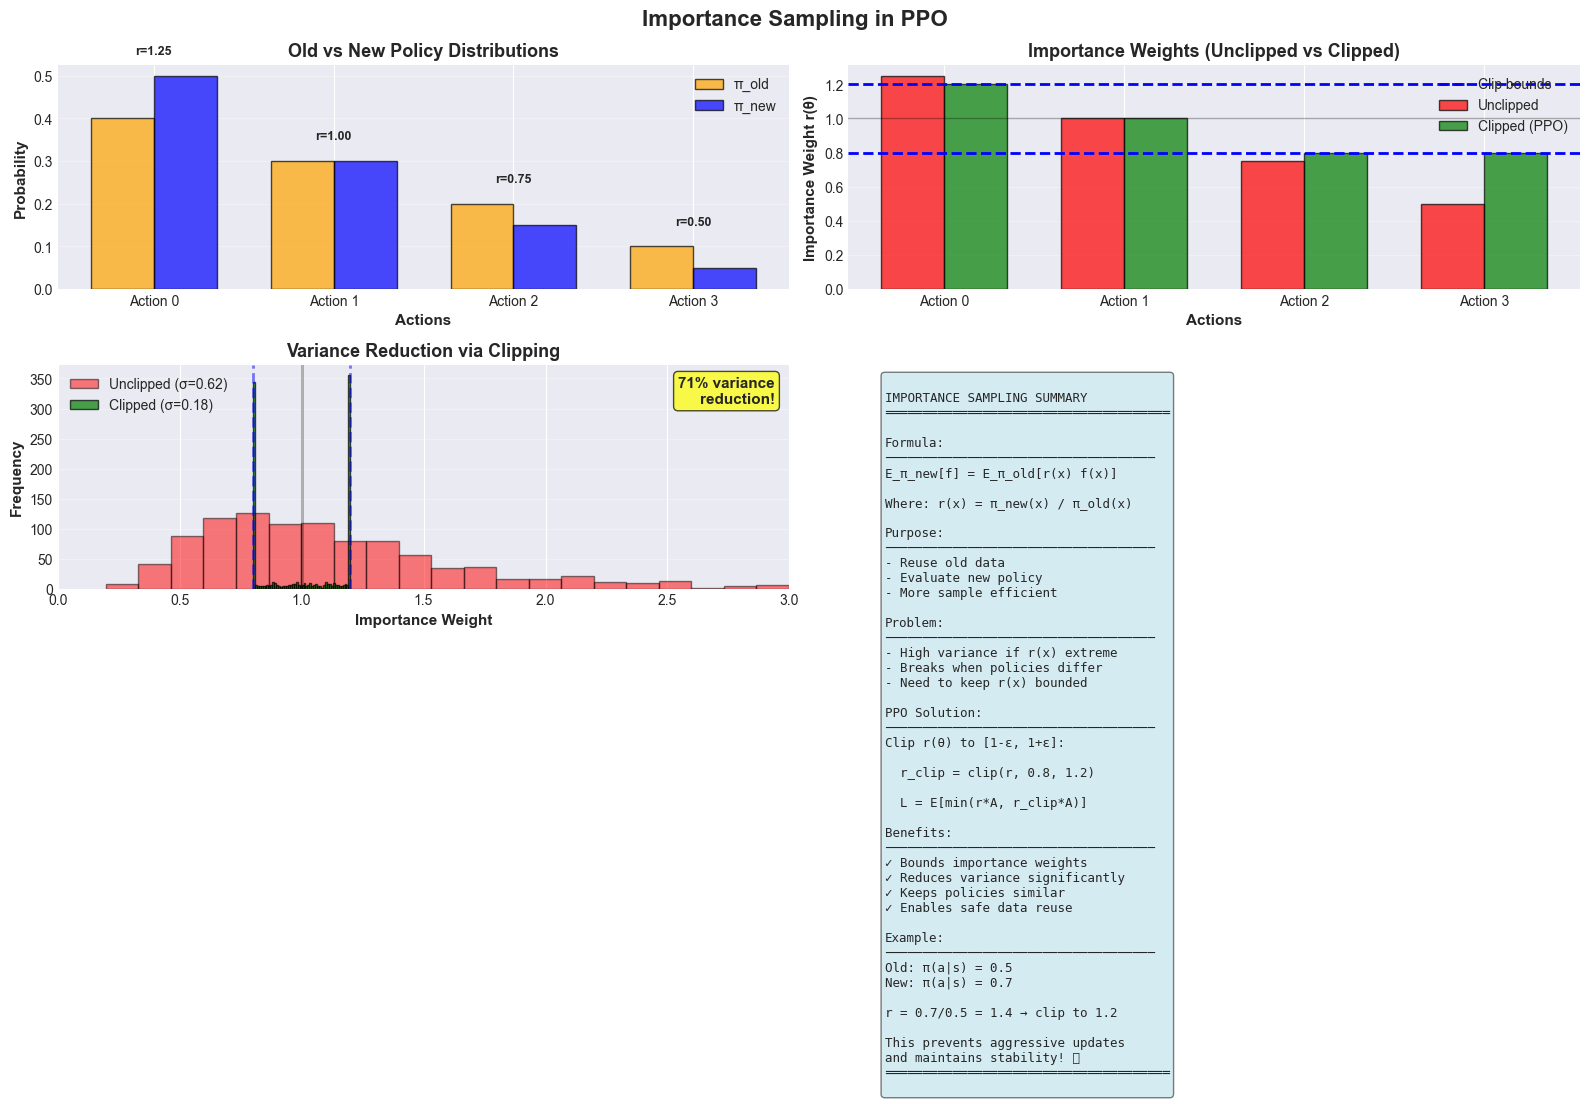


💡 Key Takeaways:

1. IMPORTANCE SAMPLING:
   • Reuse old data with new policy
   • Weight by r(θ) = π_new/π_old
   • Enables multiple epochs

2. THE PROBLEM:
   • High variance when r extreme
   • Breaks when policies differ
   • Need constraint

3. PPO'S SOLUTION:
   • Clip r to [0.8, 1.2]
   • Bounds importance weights
   • Reduces variance
   • Keeps policies similar

4. RESULT:
   • Safe data reuse
   • 3-5x sample efficiency
   • Stable training
   • Industry standard!

Next: Generalized Advantage Estimation! 🚀


✅ Exercise 2.1 Complete!


In [9]:
# ==================================================
# EXERCISE 2.1: IMPORTANCE SAMPLING IN DETAIL
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.1: Importance Sampling for Policy Gradients")
print("=" * 80)

"""
📖 THEORY: Importance Sampling

THE PROBLEM:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

We want to evaluate expectations under a new policy π_new,
but we only have data from an old policy π_old.

Standard expectation:
  E_π_new[f(x)] = Σ π_new(x) f(x)

Problem: We don't have samples from π_new yet!

IMPORTANCE SAMPLING SOLUTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Key Insight: Reweight samples from π_old

  E_π_new[f(x)] = E_π_old[π_new(x)/π_old(x) * f(x)]
                = E_π_old[r(x) * f(x)]

Where:
  r(x) = π_new(x) / π_old(x)  (importance weight)

This allows using old data with new policy! 🎯

DERIVATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Start with:
  E_π_new[f(x)] = Σ π_new(x) f(x)

Multiply and divide by π_old(x):
  = Σ π_new(x)/π_old(x) * π_old(x) f(x)
  = Σ π_old(x) * [π_new(x)/π_old(x)] * f(x)
  = E_π_old[r(x) * f(x)]

Where r(x) = π_new(x)/π_old(x) ✓

APPLICATION TO POLICY GRADIENTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Standard policy gradient:
  ∇J(θ) = E_π_θ[∇log π_θ(a|s) A(s,a)]

With importance sampling:
  ∇J(θ_new) = E_π_old[r(θ) ∇log π_θ(a|s) A(s,a)]

Where:
  r(θ) = π_θ_new(a|s) / π_θ_old(a|s)

Simplification:
  ∇log π_θ(a|s) = ∇π_θ(a|s) / π_θ(a|s)
  
So:
  r(θ) ∇log π_θ(a|s) = [π_θ_new/π_θ_old] * [∇π_θ/π_θ]
                       = ∇π_θ / π_θ_old
                       = ∇[π_θ/π_θ_old]
                       = ∇r(θ)

Therefore, objective becomes:
  L(θ) = E_π_old[r(θ) A(s,a)]

This is what PPO optimizes! 🎯

IMPORTANCE WEIGHT INTERPRETATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

r(θ) = π_new(a|s) / π_old(a|s)

r > 1: Action is MORE likely under new policy
  • Upweight this sample
  • Learn more from it
  
r = 1: Action equally likely
  • Normal weight
  • Standard learning
  
r < 1: Action is LESS likely under new policy
  • Downweight this sample
  • Learn less from it

The ratio naturally adjusts sample importance! ✓

ISSUES WITH IMPORTANCE SAMPLING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. High Variance:
   • If π_new very different from π_old
   • Importance weights become extreme
   • r(θ) can be very large or very small
   • Gradient estimates become noisy

2. Distribution Mismatch:
   • Works well when policies are similar
   • Breaks down when policies differ
   • Need to keep policies close!

This is why we need the trust region constraint! 🎯

PPO'S SOLUTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Clip the importance weights:
  r_clip(θ) = clip(r(θ), 1-ε, 1+ε)

This bounds the weights:
  • Prevents extreme values
  • Reduces variance
  • Keeps policies similar
  • Enables safe reuse of data

Objective:
  L^CLIP(θ) = E[min(r(θ)A, r_clip(θ)A)]

Conservative bound that works! 🏆

PRACTICAL EXAMPLE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Old policy: π_old(left|s) = 0.5
New policy: π_new(left|s) = 0.7

Importance weight:
  r = 0.7 / 0.5 = 1.4

Without clipping (ε=0.2):
  r > 1.2, so clip to 1.2
  
Effect:
  • Old policy would weight by 1.4
  • PPO clips to 1.2
  • Prevents over-aggressive update
  • More stable learning

This simple trick makes all the difference! ✨

COMPARISON:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A2C (On-Policy):
  • No importance sampling
  • Always uses π_current
  • r(θ) = 1 always
  • Can't reuse data

PPO (Off-Policy-ish):
  • Uses importance sampling
  • Can use π_old data
  • r(θ) = π_new/π_old
  • Reuses data multiple times
  • But clips to stay on-policy-ish!

Best of both worlds! 🎯
"""

print("\n📊 Visualizing Importance Sampling:")
print("=" * 80)

# Create importance sampling visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Importance Sampling in PPO', fontsize=16, fontweight='bold')

# 1. Policy Distributions
ax1 = axes[0, 0]

actions = np.arange(4)
pi_old = np.array([0.4, 0.3, 0.2, 0.1])
pi_new = np.array([0.5, 0.3, 0.15, 0.05])

x = np.arange(len(actions))
width = 0.35

bars1 = ax1.bar(x - width/2, pi_old, width, label='π_old', 
               alpha=0.7, edgecolor='black', color='orange')
bars2 = ax1.bar(x + width/2, pi_new, width, label='π_new',
               alpha=0.7, edgecolor='black', color='blue')

ax1.set_xlabel('Actions', fontsize=11, fontweight='bold')
ax1.set_ylabel('Probability', fontsize=11, fontweight='bold')
ax1.set_title('Old vs New Policy Distributions', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Action 0', 'Action 1', 'Action 2', 'Action 3'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add importance weights as text
for i, (old, new) in enumerate(zip(pi_old, pi_new)):
    r = new / old
    ax1.text(i, max(old, new) + 0.05, f'r={r:.2f}', 
            ha='center', fontsize=9, fontweight='bold')

# 2. Importance Weights
ax2 = axes[0, 1]

importance_weights = pi_new / pi_old
clipped_weights = np.clip(importance_weights, 0.8, 1.2)

bars1 = ax2.bar(x - width/2, importance_weights, width, 
               label='Unclipped', alpha=0.7, edgecolor='black', color='red')
bars2 = ax2.bar(x + width/2, clipped_weights, width,
               label='Clipped (PPO)', alpha=0.7, edgecolor='black', color='green')

ax2.axhline(1.2, color='blue', linestyle='--', linewidth=2, label='Clip bounds')
ax2.axhline(0.8, color='blue', linestyle='--', linewidth=2)
ax2.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.3)

ax2.set_xlabel('Actions', fontsize=11, fontweight='bold')
ax2.set_ylabel('Importance Weight r(θ)', fontsize=11, fontweight='bold')
ax2.set_title('Importance Weights (Unclipped vs Clipped)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Action 0', 'Action 1', 'Action 2', 'Action 3'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Variance Reduction
ax3 = axes[1, 0]

# Simulate variance with and without clipping
np.random.seed(42)
n_samples = 1000

# Unclipped importance weights (high variance)
unclipped_samples = np.random.lognormal(0, 0.5, n_samples)
# Clipped importance weights (lower variance)
clipped_samples = np.clip(unclipped_samples, 0.8, 1.2)

ax3.hist(unclipped_samples, bins=50, alpha=0.5, color='red',
        edgecolor='black', label=f'Unclipped (σ={np.std(unclipped_samples):.2f})')
ax3.hist(clipped_samples, bins=50, alpha=0.7, color='green',
        edgecolor='black', label=f'Clipped (σ={np.std(clipped_samples):.2f})')

ax3.axvline(1.0, color='black', linestyle='-', linewidth=2, alpha=0.3)
ax3.axvline(0.8, color='blue', linestyle='--', linewidth=2, alpha=0.5)
ax3.axvline(1.2, color='blue', linestyle='--', linewidth=2, alpha=0.5)

ax3.set_xlabel('Importance Weight', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Variance Reduction via Clipping', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xlim(0, 3)

variance_reduction = (1 - np.std(clipped_samples)/np.std(unclipped_samples)) * 100
ax3.text(0.98, 0.95, f'{variance_reduction:.0f}% variance\nreduction!',
        transform=ax3.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        fontsize=11, fontweight='bold')

# 4. Summary
ax4 = axes[1, 1]
ax4.axis('off')

summary_text = """
IMPORTANCE SAMPLING SUMMARY
══════════════════════════════════════

Formula:
────────────────────────────────────
E_π_new[f] = E_π_old[r(x) f(x)]

Where: r(x) = π_new(x) / π_old(x)

Purpose:
────────────────────────────────────
- Reuse old data
- Evaluate new policy
- More sample efficient

Problem:
────────────────────────────────────
- High variance if r(x) extreme
- Breaks when policies differ
- Need to keep r(x) bounded

PPO Solution:
────────────────────────────────────
Clip r(θ) to [1-ε, 1+ε]:

  r_clip = clip(r, 0.8, 1.2)
  
  L = E[min(r*A, r_clip*A)]

Benefits:
────────────────────────────────────
✓ Bounds importance weights
✓ Reduces variance significantly
✓ Keeps policies similar
✓ Enables safe data reuse

Example:
────────────────────────────────────
Old: π(a|s) = 0.5
New: π(a|s) = 0.7

r = 0.7/0.5 = 1.4 → clip to 1.2

This prevents aggressive updates
and maintains stability! 🎯
══════════════════════════════════════
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/importance_sampling.png', dpi=300, bbox_inches='tight')
print("✅ Importance sampling visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. IMPORTANCE SAMPLING:
   • Reuse old data with new policy
   • Weight by r(θ) = π_new/π_old
   • Enables multiple epochs

2. THE PROBLEM:
   • High variance when r extreme
   • Breaks when policies differ
   • Need constraint

3. PPO'S SOLUTION:
   • Clip r to [0.8, 1.2]
   • Bounds importance weights
   • Reduces variance
   • Keeps policies similar

4. RESULT:
   • Safe data reuse
   • 3-5x sample efficiency
   • Stable training
   • Industry standard!

Next: Generalized Advantage Estimation! 🚀
""")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.2: Generalized Advantage Estimation (GAE)

📊 Visualizing GAE:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\3563038411.py:332: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\3563038411.py:333: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/gae.png', dpi=300, bbox_inches='tight')


✅ GAE visualization saved!


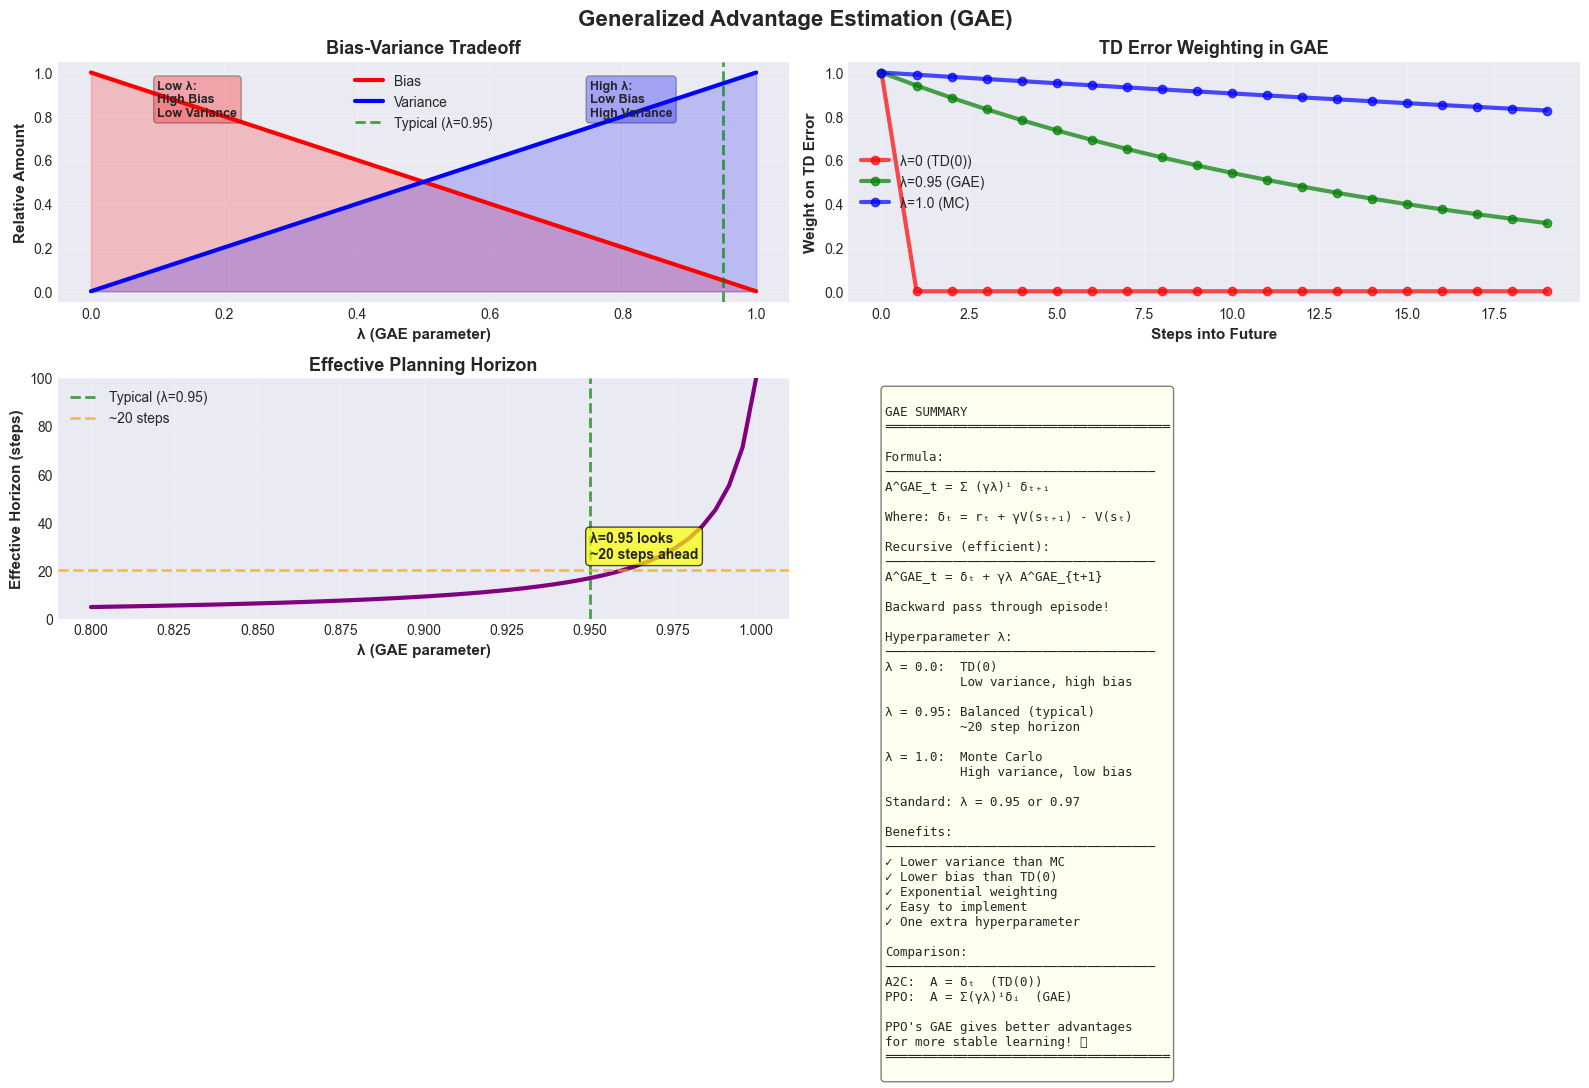


💡 Key Takeaways:

1. GAE = Generalized Advantage Estimation
   • Exponentially-weighted n-step advantages
   • Formula: A = Σ (γλ)ⁱ δᵢ
   • Balances bias and variance

2. HYPERPARAMETER λ:
   • λ = 0: TD(0) (low variance, high bias)
   • λ = 0.95: Balanced (typical)
   • λ = 1: MC (high variance, low bias)

3. BENEFITS:
   • Lower variance than pure MC
   • Lower bias than TD(0)
   • Easy to implement
   • Works great in practice

4. WHY PPO USES IT:
   • Better advantage estimates
   • More stable learning
   • Combined with clipping = powerful!

Next: Complete PPO algorithm! 🚀


✅ Exercise 2.2 Complete!


In [10]:
# ==================================================
# EXERCISE 2.2: GENERALIZED ADVANTAGE ESTIMATION (GAE)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.2: Generalized Advantage Estimation (GAE)")
print("=" * 80)

"""
📖 THEORY: GAE - Advanced Advantage Computation

ADVANTAGE FUNCTION RECAP:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A(s,a) = Q(s,a) - V(s)
       = "How much better is action a than average?"

In practice (A2C):
  A(s,a) = r + γV(s') - V(s)  [TD(0)]

This is simple but has high variance!

THE BIAS-VARIANCE TRADEOFF:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Different ways to compute advantages:

1. Monte Carlo (n=∞):
   A = R - V(s)
   R = r₀ + γr₁ + γ²r₂ + ... + γᵀrᵀ
   
   • No bias (true return)
   • High variance (many random steps)

2. TD(0) (n=1):
   A = r + γV(s') - V(s)
   
   • Some bias (bootstrapped V)
   • Low variance (one step)

3. TD(n) (n steps):
   A = r₀ + γr₁ + ... + γⁿ⁻¹rₙ₋₁ + γⁿV(sₙ) - V(s)
   
   • Balance bias and variance
   • n controls the tradeoff

Question: Can we do better than picking single n? 🤔

GAE: BEST OF ALL WORLDS!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

GAE (Generalized Advantage Estimation):
  Exponentially-weighted average of ALL n-step advantages!

Formula:
  A^GAE = (1-λ) Σ λⁿ A^(n)
  
Where:
  λ ∈ [0,1] controls bias-variance tradeoff
  A^(n) = n-step advantage

Special cases:
  λ = 0: A^GAE = TD(0)  (low variance, high bias)
  λ = 1: A^GAE = MC     (high variance, low bias)
  λ = 0.95: Balanced (typical choice)

EFFICIENT COMPUTATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TD error at time t:
  δₜ = rₜ + γV(sₜ₊₁) - V(sₜ)

GAE can be computed recursively:
  A^GAE_t = Σ (γλ)ⁱ δₜ₊ᵢ
  
Backward computation:
  A^GAE_t = δₜ + γλ A^GAE_{t+1}

This is MUCH more efficient! 🎯

INTUITION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

GAE looks into the future with exponentially decaying weights:

  A = δₜ + (γλ)δₜ₊₁ + (γλ)²δₜ₊₂ + (γλ)³δₜ₊₃ + ...

Recent TD errors get more weight (λ < 1):
  • Close rewards are more reliable
  • Distant rewards have more uncertainty
  • Natural decay makes sense!

Why this works:
  • Combines multiple temporal horizons
  • Reduces variance vs pure MC
  • Low bias with λ close to 1
  • Best of both worlds! 🎯

HYPERPARAMETER λ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

λ = 0.0:
  A = δₜ only (TD(0))
  • Lowest variance
  • Highest bias
  • Myopic (only 1 step ahead)

λ = 0.95 (typical):
  A = weighted sum of δₜ, δₜ₊₁, ...
  • Balanced bias-variance
  • Looks ~20 steps ahead effectively
  • Good default choice

λ = 1.0:
  A = full Monte Carlo
  • No bias
  • Highest variance
  • Not recommended alone

Standard: λ = 0.95 or 0.97 works well! ✓

WHY PPO USES GAE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Lower Variance:
   • Better than pure MC
   • More stable gradients
   • Faster learning

2. Low Bias:
   • Better than TD(0) with λ close to 1
   • More accurate advantages
   • Better policy updates

3. Practical:
   • Easy to implement
   • Fast to compute
   • One extra hyperparameter (λ)
   • Works well in practice

GAE + Clipping = PPO's success! 🏆

IMPLEMENTATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def compute_gae(rewards, values, next_value, dones, gamma, lambda_):
    advantages = []
    gae = 0
    
    # Backward pass
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_val = next_value
        else:
            next_val = values[t + 1]
        
        # TD error
        delta = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
        
        # GAE
        gae = delta + gamma * lambda_ * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    
    return advantages

Simple and elegant! ✨

COMPARISON:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A2C (Simple):
  A = r + γV(s') - V(s)
  • Just TD(0)
  • Higher variance
  • Faster to compute

PPO (GAE):
  A = Σ (γλ)ⁱ δᵢ
  • Weighted average of all n-step
  • Lower variance
  • Slightly more computation
  • Better results in practice

Worth the extra complexity! 🎯
"""

print("\n📊 Visualizing GAE:")
print("=" * 80)

# Create GAE visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Generalized Advantage Estimation (GAE)', fontsize=16, fontweight='bold')

# 1. Bias-Variance Tradeoff
ax1 = axes[0, 0]

lambda_values = np.linspace(0, 1, 100)
bias = 1 - lambda_values  # More bias with lower lambda
variance = lambda_values  # More variance with higher lambda

ax1.plot(lambda_values, bias, linewidth=3, label='Bias', color='red')
ax1.plot(lambda_values, variance, linewidth=3, label='Variance', color='blue')
ax1.fill_between(lambda_values, 0, bias, alpha=0.2, color='red')
ax1.fill_between(lambda_values, 0, variance, alpha=0.2, color='blue')

ax1.axvline(0.95, color='green', linestyle='--', linewidth=2, 
           label='Typical (λ=0.95)', alpha=0.7)

ax1.set_xlabel('λ (GAE parameter)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Relative Amount', fontsize=11, fontweight='bold')
ax1.set_title('Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate
ax1.text(0.1, 0.8, 'Low λ:\nHigh Bias\nLow Variance', 
        bbox=dict(boxstyle='round', facecolor='red', alpha=0.3),
        fontsize=9, fontweight='bold')
ax1.text(0.75, 0.8, 'High λ:\nLow Bias\nHigh Variance',
        bbox=dict(boxstyle='round', facecolor='blue', alpha=0.3),
        fontsize=9, fontweight='bold')

# 2. TD Error Weights
ax2 = axes[0, 1]

steps = np.arange(0, 20)
gamma = 0.99
lambda_vals = [0.0, 0.95, 1.0]
colors = ['red', 'green', 'blue']
labels = ['λ=0 (TD(0))', 'λ=0.95 (GAE)', 'λ=1.0 (MC)']

for lam, color, label in zip(lambda_vals, colors, labels):
    if lam == 0:
        weights = np.zeros(len(steps))
        weights[0] = 1
    elif lam == 1.0:
        weights = (gamma ** steps)
    else:
        weights = (gamma * lam) ** steps
    
    ax2.plot(steps, weights, linewidth=3, marker='o', 
            color=color, label=label, alpha=0.7)

ax2.set_xlabel('Steps into Future', fontsize=11, fontweight='bold')
ax2.set_ylabel('Weight on TD Error', fontsize=11, fontweight='bold')
ax2.set_title('TD Error Weighting in GAE', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Effective Horizon
ax3 = axes[1, 0]

lambda_range = np.linspace(0.8, 1.0, 50)
gamma = 0.99

# Effective horizon ≈ 1 / (1 - γλ)
effective_horizon = 1 / (1 - gamma * lambda_range)

ax3.plot(lambda_range, effective_horizon, linewidth=3, color='purple')
ax3.axvline(0.95, color='green', linestyle='--', linewidth=2,
           label='Typical (λ=0.95)', alpha=0.7)
ax3.axhline(20, color='orange', linestyle='--', linewidth=2,
           label='~20 steps', alpha=0.7)

ax3.set_xlabel('λ (GAE parameter)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Effective Horizon (steps)', fontsize=11, fontweight='bold')
ax3.set_title('Effective Planning Horizon', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 100)

# Annotate
ax3.text(0.95, 25, 'λ=0.95 looks\n~20 steps ahead',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        fontsize=10, fontweight='bold')

# 4. GAE Summary
ax4 = axes[1, 1]
ax4.axis('off')

gae_text = """
GAE SUMMARY
══════════════════════════════════════

Formula:
────────────────────────────────────
A^GAE_t = Σ (γλ)ⁱ δₜ₊ᵢ

Where: δₜ = rₜ + γV(sₜ₊₁) - V(sₜ)

Recursive (efficient):
────────────────────────────────────
A^GAE_t = δₜ + γλ A^GAE_{t+1}

Backward pass through episode!

Hyperparameter λ:
────────────────────────────────────
λ = 0.0:  TD(0)
          Low variance, high bias
          
λ = 0.95: Balanced (typical)
          ~20 step horizon
          
λ = 1.0:  Monte Carlo
          High variance, low bias

Standard: λ = 0.95 or 0.97

Benefits:
────────────────────────────────────
✓ Lower variance than MC
✓ Lower bias than TD(0)
✓ Exponential weighting
✓ Easy to implement
✓ One extra hyperparameter

Comparison:
────────────────────────────────────
A2C:  A = δₜ  (TD(0))
PPO:  A = Σ(γλ)ⁱδᵢ  (GAE)

PPO's GAE gives better advantages
for more stable learning! 🎯
══════════════════════════════════════
"""

ax4.text(0.05, 0.95, gae_text, transform=ax4.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/gae.png', dpi=300, bbox_inches='tight')
print("✅ GAE visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. GAE = Generalized Advantage Estimation
   • Exponentially-weighted n-step advantages
   • Formula: A = Σ (γλ)ⁱ δᵢ
   • Balances bias and variance

2. HYPERPARAMETER λ:
   • λ = 0: TD(0) (low variance, high bias)
   • λ = 0.95: Balanced (typical)
   • λ = 1: MC (high variance, low bias)

3. BENEFITS:
   • Lower variance than pure MC
   • Lower bias than TD(0)
   • Easy to implement
   • Works great in practice

4. WHY PPO USES IT:
   • Better advantage estimates
   • More stable learning
   • Combined with clipping = powerful!

Next: Complete PPO algorithm! 🚀
""")

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)


EXERCISE 2.3: Complete PPO Algorithm

📊 Visualizing Complete PPO Algorithm:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1009413903.py:403: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1009413903.py:404: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/ppo_algorithm.png', dpi=300, bbox_inches='tight')


✅ PPO algorithm visualization saved!


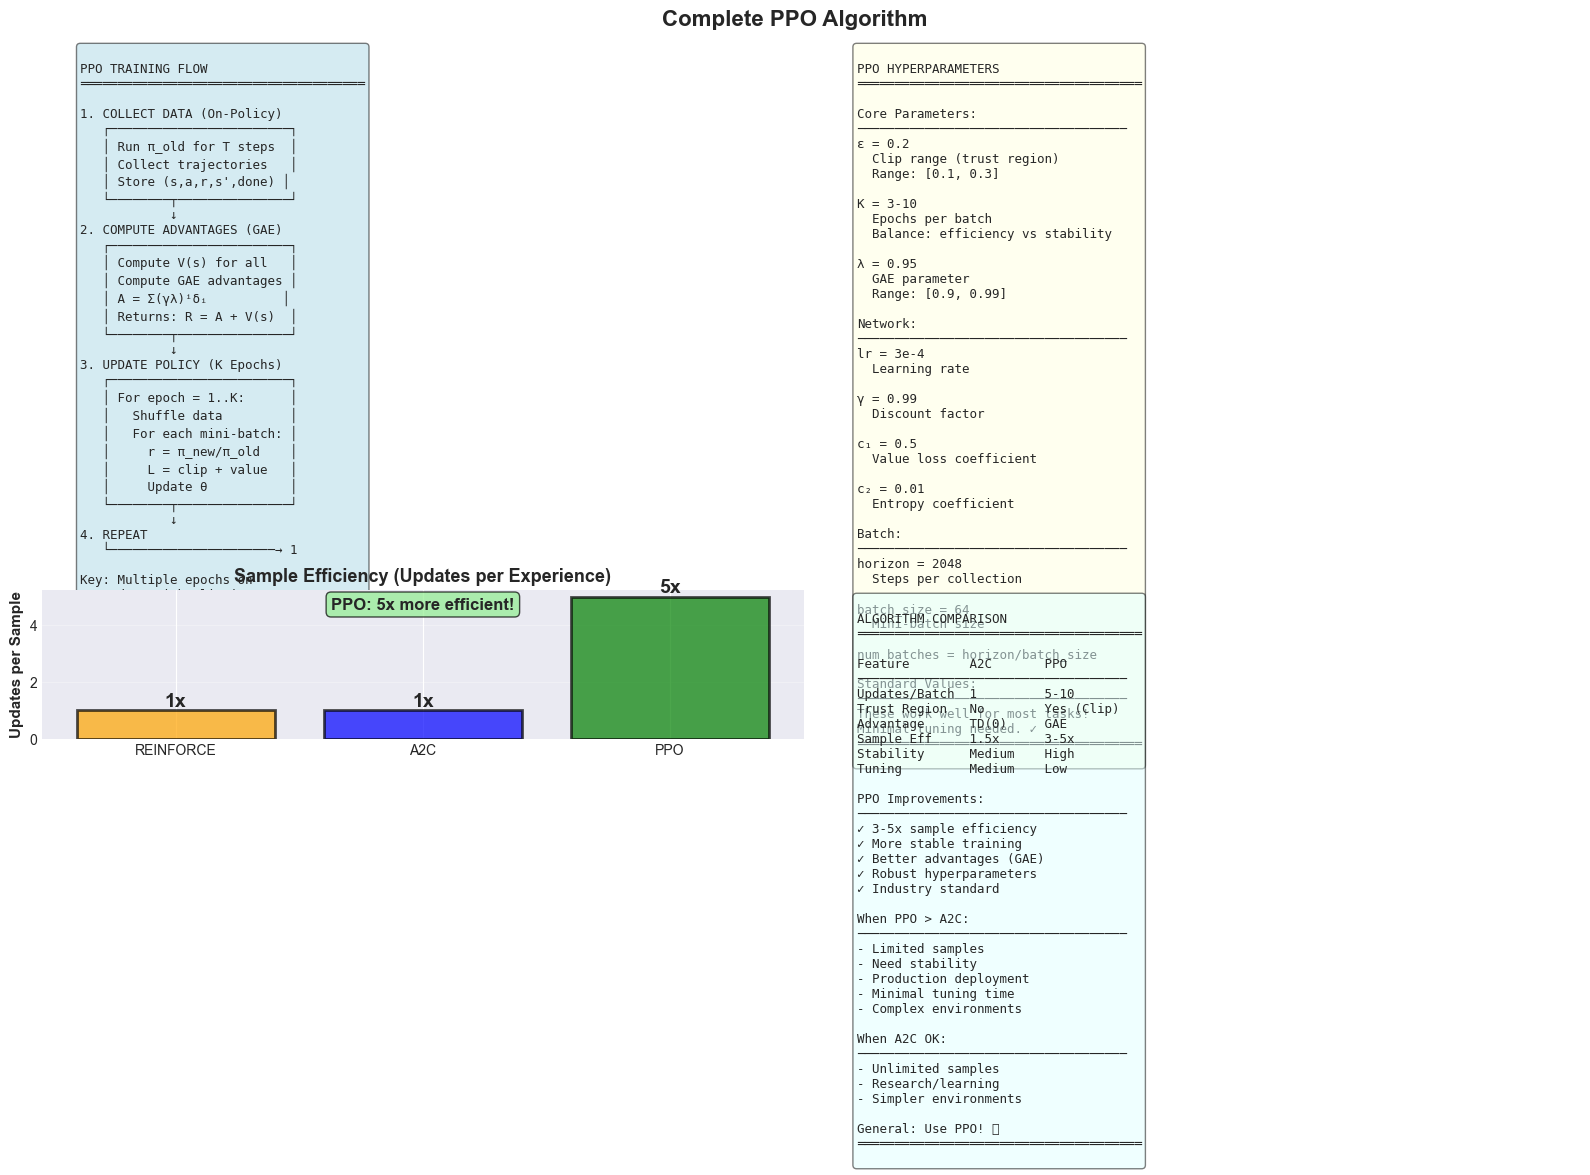


💡 Key Takeaways:

1. COMPLETE PPO:
   • Clipped objective (trust region)
   • GAE advantages (low variance)
   • Multiple epochs (sample efficient)
   • Entropy bonus (exploration)

2. ALGORITHM FLOW:
   • Collect trajectories
   • Compute GAE advantages
   • Update K epochs (K=3-10)
   • Repeat

3. KEY HYPERPARAMETERS:
   • ε = 0.2 (clip range)
   • K = 3-10 (epochs)
   • λ = 0.95 (GAE)
   • Standard values work well!

4. WHY IT WORKS:
   • 3-5x sample efficiency
   • Stable updates (clipping)
   • Better advantages (GAE)
   • Simple and practical

Next: Implementation! 🚀


✅ Exercise 2.3 Complete!


In [11]:
# ==================================================
# EXERCISE 2.3: COMPLETE PPO ALGORITHM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.3: Complete PPO Algorithm")
print("=" * 80)

"""
📖 THEORY: The Complete PPO Algorithm

PUTTING IT ALL TOGETHER:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PPO combines:
1. Clipped surrogate objective (trust region)
2. Importance sampling (data reuse)
3. GAE (better advantages)
4. Multiple epochs (sample efficiency)

THE PPO OBJECTIVE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Total Loss:
  L = L^CLIP - c₁*L^VF + c₂*L^S

Components:

1. Clipped Policy Loss (Actor):
   L^CLIP(θ) = -E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
   
   Where: r(θ) = π_θ(a|s) / π_θ_old(a|s)

2. Value Function Loss (Critic):
   L^VF(θ) = E[(V_θ(s) - V^target)²]
   
   Where: V^target = A^GAE + V(s)

3. Entropy Bonus (Exploration):
   L^S(θ) = E[H(π_θ(·|s))]
   
   Where: H = -Σ π(a|s) log π(a|s)

Coefficients:
  c₁ = 0.5 (value loss weight)
  c₂ = 0.01 (entropy weight)
  ε = 0.2 (clip parameter)

PPO ALGORITHM PSEUDOCODE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Initialize policy network π_θ (actor) and value network V_w (critic)

for iteration = 1, 2, ... do:
    
    # Collect trajectories
    Run policy π_θ_old in environment for T timesteps
    Collect: (s, a, r, s', done) for each timestep
    
    # Compute advantages using GAE
    Compute V(s) for all states using V_w
    Compute advantages A^GAE using λ=0.95
    Compute returns: R = A + V(s)
    
    # Store old policy
    Store π_θ_old(a|s) for all (s,a) pairs
    
    # Optimize for K epochs
    for epoch = 1, 2, ..., K do:
        
        # Mini-batch updates
        for mini-batch in data do:
            
            # Compute ratio
            r(θ) = π_θ(a|s) / π_θ_old(a|s)
            
            # Clipped objective
            L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
            
            # Value loss
            L^VF = (V_θ(s) - R)²
            
            # Entropy
            L^S = H(π_θ)
            
            # Total loss
            L = -L^CLIP + c₁*L^VF - c₂*L^S
            
            # Update
            θ ← θ - α∇L
        end
    end
end

KEY DIFFERENCES FROM A2C:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A2C:
  • Collect batch
  • Single gradient update
  • Throw away data
  • Move to next batch

PPO:
  • Collect batch
  • Store π_old probabilities
  • K epochs of updates (K=3-10)
  • Clipped objective prevents divergence
  • Much more sample efficient!

HYPERPARAMETERS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Critical Parameters:
  ε = 0.2         Clip range (trust region size)
  K = 3-10        Number of epochs per batch
  λ = 0.95        GAE parameter
  γ = 0.99        Discount factor
  
  c₁ = 0.5        Value loss coefficient
  c₂ = 0.01       Entropy coefficient
  
  lr = 3e-4       Learning rate
  batch = 64      Mini-batch size
  horizon = 2048  Steps per batch

Standard values work well across many tasks! ✓

TRAINING FLOW:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Collect Data Phase:
   • Run current policy in environment
   • Collect trajectories (2048 steps typical)
   • Store: states, actions, rewards, values, log_probs

2. Compute Advantages Phase:
   • Use GAE to compute advantages
   • Compute returns: R = A + V(s)
   • Normalize advantages

3. Update Phase (K epochs):
   • Shuffle data into mini-batches
   • For each mini-batch:
     * Compute new π(a|s)
     * Compute ratio r = π_new/π_old
     * Compute clipped loss
     * Update policy and value networks
   • Repeat K times (K=3-10)

4. Repeat!

WHY THIS WORKS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Data Efficiency:
   • K epochs per batch
   • 3-10x more updates per sample
   • Clipping keeps it safe

2. Stable Updates:
   • Trust region constraint (clipping)
   • Conservative policy changes
   • No policy collapse

3. Better Advantages:
   • GAE reduces variance
   • More accurate advantage estimates
   • Better gradient direction

4. Simple:
   • First-order optimization
   • Easy to implement
   • Fast to compute

PPO = Practical + Powerful! 🏆

EARLY STOPPING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Optional: Monitor KL divergence during updates

If D_KL(π_old || π_new) > threshold:
  • Stop updating for this batch
  • Policy has changed too much
  • Prevents over-optimization

This is used in some implementations for extra safety.

COMPARISON TO OTHER METHODS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

┌──────────────┬─────────┬─────────┬─────────┬─────────┐
│   Feature    │REINFORCE│   A2C   │  TRPO   │   PPO   │
├──────────────┼─────────┼─────────┼─────────┼─────────┤
│ Baseline     │Constant │  V(s)   │  V(s)   │  V(s)   │
│ Advantage    │  MC     │  TD(0)  │  GAE    │  GAE    │
│ Trust Region │   No    │   No    │Hard (KL)│Soft(Clip)│
│ Epochs       │    1    │    1    │    1    │  3-10   │
│ Sample Eff   │  1.0x   │  1.5x   │  2.0x   │  3-5x   │
│ Complexity   │  Low    │  Low    │  High   │ Medium  │
│ Stability    │  Low    │ Medium  │  High   │  High   │
└──────────────┴─────────┴─────────┴─────────┴─────────┘

PPO achieves TRPO-level performance with A2C-level simplicity! 🎯

WHEN TO USE PPO:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Use PPO when:
  ✓ Need sample efficiency
  ✓ Want stable training
  ✓ Continuous or discrete actions
  ✓ Production deployment
  ✓ Limited compute budget
  ✓ Want robust algorithm

PPO is the default choice for modern RL! 🏆
"""

print("\n📊 Visualizing Complete PPO Algorithm:")
print("=" * 80)

# Create algorithm flowchart
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Complete PPO Algorithm', fontsize=16, fontweight='bold')

# 1. Training Flow
ax1 = axes[0, 0]
ax1.axis('off')

flow_text = """
PPO TRAINING FLOW
══════════════════════════════════════

1. COLLECT DATA (On-Policy)
   ┌────────────────────────┐
   │ Run π_old for T steps  │
   │ Collect trajectories   │
   │ Store (s,a,r,s',done) │
   └────────┬───────────────┘
            ↓
2. COMPUTE ADVANTAGES (GAE)
   ┌────────────────────────┐
   │ Compute V(s) for all   │
   │ Compute GAE advantages │
   │ A = Σ(γλ)ⁱδᵢ          │
   │ Returns: R = A + V(s)  │
   └────────┬───────────────┘
            ↓
3. UPDATE POLICY (K Epochs)
   ┌────────────────────────┐
   │ For epoch = 1..K:      │
   │   Shuffle data         │
   │   For each mini-batch: │
   │     r = π_new/π_old    │
   │     L = clip + value   │
   │     Update θ           │
   └────────┬───────────────┘
            ↓
4. REPEAT
   └──────────────────────→ 1

Key: Multiple epochs on
same data with clipping! 🎯
══════════════════════════════════════
"""

ax1.text(0.05, 0.95, flow_text, transform=ax1.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 2. Hyperparameters
ax2 = axes[0, 1]
ax2.axis('off')

hyperparam_text = """
PPO HYPERPARAMETERS
══════════════════════════════════════

Core Parameters:
────────────────────────────────────
ε = 0.2
  Clip range (trust region)
  Range: [0.1, 0.3]
  
K = 3-10
  Epochs per batch
  Balance: efficiency vs stability
  
λ = 0.95
  GAE parameter
  Range: [0.9, 0.99]

Network:
────────────────────────────────────
lr = 3e-4
  Learning rate
  
γ = 0.99
  Discount factor

c₁ = 0.5
  Value loss coefficient
  
c₂ = 0.01
  Entropy coefficient

Batch:
────────────────────────────────────
horizon = 2048
  Steps per collection
  
batch_size = 64
  Mini-batch size
  
num_batches = horizon/batch_size

Standard Values:
────────────────────────────────────
These work well for most tasks!
Minimal tuning needed. ✓
══════════════════════════════════════
"""

ax2.text(0.05, 0.95, hyperparam_text, transform=ax2.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# 3. Sample Efficiency Comparison
ax3 = axes[1, 0]

methods = ['REINFORCE', 'A2C', 'PPO']
updates_per_sample = [1, 1, 5]  # Typical values
colors = ['orange', 'blue', 'green']

bars = ax3.bar(methods, updates_per_sample, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=2)

ax3.set_ylabel('Updates per Sample', fontsize=11, fontweight='bold')
ax3.set_title('Sample Efficiency (Updates per Experience)', 
             fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for bar, updates in zip(bars, updates_per_sample):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{updates}x', ha='center', va='bottom', 
            fontweight='bold', fontsize=14)

ax3.text(0.5, 0.95, 'PPO: 5x more efficient!',
        transform=ax3.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        fontsize=12, fontweight='bold')

# 4. Algorithm Comparison
ax4 = axes[1, 1]
ax4.axis('off')

comparison_text = """
ALGORITHM COMPARISON
══════════════════════════════════════

Feature        A2C       PPO
────────────────────────────────────
Updates/Batch  1         5-10
Trust Region   No        Yes (Clip)
Advantage      TD(0)     GAE
Sample Eff     1.5x      3-5x
Stability      Medium    High
Tuning         Medium    Low

PPO Improvements:
────────────────────────────────────
✓ 3-5x sample efficiency
✓ More stable training
✓ Better advantages (GAE)
✓ Robust hyperparameters
✓ Industry standard

When PPO > A2C:
────────────────────────────────────
- Limited samples
- Need stability
- Production deployment
- Minimal tuning time
- Complex environments

When A2C OK:
────────────────────────────────────
- Unlimited samples
- Research/learning
- Simpler environments

General: Use PPO! 🎯
══════════════════════════════════════
"""

ax4.text(0.05, 0.95, comparison_text, transform=ax4.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/ppo_algorithm.png', dpi=300, bbox_inches='tight')
print("✅ PPO algorithm visualization saved!")
plt.show()

print("\n💡 Key Takeaways:")
print("=" * 80)
print("""
1. COMPLETE PPO:
   • Clipped objective (trust region)
   • GAE advantages (low variance)
   • Multiple epochs (sample efficient)
   • Entropy bonus (exploration)

2. ALGORITHM FLOW:
   • Collect trajectories
   • Compute GAE advantages
   • Update K epochs (K=3-10)
   • Repeat

3. KEY HYPERPARAMETERS:
   • ε = 0.2 (clip range)
   • K = 3-10 (epochs)
   • λ = 0.95 (GAE)
   • Standard values work well!

4. WHY IT WORKS:
   • 3-5x sample efficiency
   • Stable updates (clipping)
   • Better advantages (GAE)
   • Simple and practical

Next: Implementation! 🚀
""")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)

In [12]:
# ==================================================
# EXERCISE 2.4: PART 2 SUMMARY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.4: Part 2 - Mathematical Framework Summary")
print("=" * 80)

print("""
📚 PART 2 COMPLETED:

✅ Importance Sampling:
   • Reuse old data with new policy
   • Weight by r(θ) = π_new/π_old
   • PPO clips r to [0.8, 1.2]
   • Reduces variance, enables multiple epochs

✅ Generalized Advantage Estimation (GAE):
   • A^GAE = Σ (γλ)ⁱ δᵢ
   • Balances bias and variance
   • λ = 0.95 typical
   • Better than TD(0) or pure MC

✅ Complete PPO Algorithm:
   • Collect trajectories
   • Compute GAE advantages
   • Update K epochs with clipping
   • Repeat

✅ Key Components:
   • Clipped policy loss: L^CLIP
   • Value function loss: L^VF
   • Entropy bonus: L^S
   • Total: L = -L^CLIP + c₁*L^VF - c₂*L^S

📐 PPO Formula Summary:

Complete Objective:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L_total = -L^CLIP + c₁*L^VF - c₂*L^S

Where:
  L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
  L^VF = E[(V(s) - R)²]
  L^S = E[H(π)]
  
  r(θ) = π_new(a|s) / π_old(a|s)
  A = GAE advantage
  R = A + V(s)

Standard Hyperparameters:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ε = 0.2   (clip range)
K = 5     (epochs per batch)
λ = 0.95  (GAE parameter)
γ = 0.99  (discount)
c₁ = 0.5  (value coefficient)
c₂ = 0.01 (entropy coefficient)
lr = 3e-4 (learning rate)

These work well across many tasks! ✓

Mathematical Components:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Policy Ratio:
   r(θ) = π_new(a|s) / π_old(a|s)
   • Enables importance sampling
   • Allows data reuse

2. Clipping:
   r_clip = clip(r, 1-ε, 1+ε)
   • Creates trust region
   • Prevents policy collapse
   • Key innovation!

3. Min Operator:
   min(r*A, r_clip*A)
   • Conservative bound
   • Only improve when safe
   • Ensures stability

4. GAE:
   A = Σ (γλ)ⁱ δᵢ
   • Lower variance than MC
   • Lower bias than TD(0)
   • Optimal balance

Algorithm Evolution Complete:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REINFORCE (1992):
  ∇J = E[∇log π R]
  • Basic policy gradient
  • High variance
  
A2C (2017):
  ∇J = E[∇log π A]
  A = r + γV(s') - V(s)
  • Add value baseline
  • Lower variance
  
PPO (2017):
  L = E[min(r*A, clip(r)*A)]
  A = GAE
  • Add trust region
  • Multiple epochs
  • Lower variance
  • Sample efficient
  • State-of-the-art! 🏆

Why PPO Succeeded:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Simple to implement (vs TRPO)
✓ Sample efficient (multiple epochs)
✓ Stable (clipped objective)
✓ Robust (good defaults)
✓ Practical (1st order)
✓ Proven (industry use)

PPO = The RL Workhorse! 💪

🎯 NEXT: Part 3 - PPO Implementation

We'll implement:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Actor-Critic network for PPO
- GAE computation
- PPO agent class
- Complete training loop
- All the math we just learned!

Ready to code! 💻🚀
""")

print("=" * 80)
print("✅ Part 2 Complete!")
print("=" * 80)


EXERCISE 2.4: Part 2 - Mathematical Framework Summary

📚 PART 2 COMPLETED:

✅ Importance Sampling:
   • Reuse old data with new policy
   • Weight by r(θ) = π_new/π_old
   • PPO clips r to [0.8, 1.2]
   • Reduces variance, enables multiple epochs

✅ Generalized Advantage Estimation (GAE):
   • A^GAE = Σ (γλ)ⁱ δᵢ
   • Balances bias and variance
   • λ = 0.95 typical
   • Better than TD(0) or pure MC

✅ Complete PPO Algorithm:
   • Collect trajectories
   • Compute GAE advantages
   • Update K epochs with clipping
   • Repeat

✅ Key Components:
   • Clipped policy loss: L^CLIP
   • Value function loss: L^VF
   • Entropy bonus: L^S
   • Total: L = -L^CLIP + c₁*L^VF - c₂*L^S

📐 PPO Formula Summary:

Complete Objective:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L_total = -L^CLIP + c₁*L^VF - c₂*L^S

Where:
  L^CLIP = E[min(r(θ)A, clip(r(θ), 1-ε, 1+ε)A)]
  L^VF = E[(V(s) - R)²]
  L^S = E[H(π)]

  r(θ) = π_new(a|s) / π_old(a|s)
  A = GAE advantage
  R = A + V(s)

Stand

In [13]:
print("\n" + "=" * 80)
print("💻 PART 3: PPO IMPLEMENTATION")
print("=" * 80)


💻 PART 3: PPO IMPLEMENTATION


In [14]:
# ==================================================
# EXERCISE 3.1: PPO ACTOR-CRITIC NETWORK
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.1: PPO Network Architecture")
print("=" * 80)

"""
📖 THEORY: PPO Network Design

PPO uses the same Actor-Critic architecture as A2C:
  • Shared feature extraction
  • Actor head (policy)
  • Critic head (value)

Difference is in HOW we train it, not the architecture!
"""

print("\n🧠 Implementing PPO Network:")
print("=" * 80)

class PPONetwork(nn.Module):
    """
    PPO Actor-Critic Network
    Same architecture as A2C, different training!
    """
    
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PPONetwork, self).__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        
        # Shared layers
        self.shared_fc1 = nn.Linear(state_dim, hidden_dim)
        self.shared_fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Actor head
        self.actor_fc = nn.Linear(hidden_dim, action_dim)
        
        # Critic head
        self.critic_fc = nn.Linear(hidden_dim, 1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Xavier initialization"""
        for layer in [self.shared_fc1, self.shared_fc2, self.actor_fc, self.critic_fc]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    def forward(self, state):
        """Forward pass"""
        x = F.relu(self.shared_fc1(state))
        x = F.relu(self.shared_fc2(x))
        
        logits = self.actor_fc(x)
        value = self.critic_fc(x)
        
        return logits, value
    
    def get_action_and_value(self, state, action=None):
        """
        Get action and value
        If action provided, evaluate it
        Otherwise, sample new action
        """
        state = torch.FloatTensor(state).to(device)
        logits, value = self.forward(state)
        
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        
        if action is None:
            # Sample action
            action = dist.sample()
        else:
            # Evaluate provided action
            action = torch.LongTensor([action]).to(device)
        
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        
        return action.item() if action.dim() == 0 else action, log_prob, value.squeeze(), entropy
    
    def evaluate_actions(self, states, actions):
        """Evaluate batch of actions"""
        logits, values = self.forward(states)
        
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        
        return log_probs, values.squeeze(), entropy

print("✅ PPONetwork implemented!")

# Test network
print("\n🧪 Testing PPO Network:")
print("-" * 80)

network = PPONetwork(state_dim=4, action_dim=2, hidden_dim=128).to(device)

print(f"Network created:")
print(f"  State dim: 4")
print(f"  Action dim: 2")
print(f"  Hidden dim: 128")

# Count parameters
total_params = sum(p.numel() for p in network.parameters())
shared_params = sum(p.numel() for p in list(network.shared_fc1.parameters()) + list(network.shared_fc2.parameters()))
actor_params = sum(p.numel() for p in network.actor_fc.parameters())
critic_params = sum(p.numel() for p in network.critic_fc.parameters())

print(f"\n📊 Parameter Breakdown:")
print(f"  Total: {total_params:,}")
print(f"  Shared: {shared_params:,} ({shared_params/total_params*100:.1f}%)")
print(f"  Actor: {actor_params:,} ({actor_params/total_params*100:.1f}%)")
print(f"  Critic: {critic_params:,} ({critic_params/total_params*100:.1f}%)")

# Test forward pass
test_state = torch.randn(4).to(device)
logits, value = network(test_state)

print(f"\n🔍 Test Forward Pass:")
print(f"  Input shape: {test_state.shape}")
print(f"  Logits shape: {logits.shape}")
print(f"  Value shape: {value.shape}")
print(f"  Value: {value.item():.4f}")

# Test action sampling
action, log_prob, value, entropy = network.get_action_and_value(test_state.cpu().numpy())
print(f"\n🎯 Test Action Sampling:")
print(f"  Action: {action}")
print(f"  Log prob: {log_prob.item():.4f}")
print(f"  Value: {value.item():.4f}")
print(f"  Entropy: {entropy.item():.4f}")

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: PPO Network Architecture

🧠 Implementing PPO Network:
✅ PPONetwork implemented!

🧪 Testing PPO Network:
--------------------------------------------------------------------------------
Network created:
  State dim: 4
  Action dim: 2
  Hidden dim: 128

📊 Parameter Breakdown:
  Total: 17,539
  Shared: 17,152 (97.8%)
  Actor: 258 (1.5%)
  Critic: 129 (0.7%)

🔍 Test Forward Pass:
  Input shape: torch.Size([4])
  Logits shape: torch.Size([2])
  Value shape: torch.Size([1])
  Value: 0.1105

🎯 Test Action Sampling:
  Action: 1
  Log prob: -0.6941
  Value: 0.1105
  Entropy: 0.6931

✅ Exercise 3.1 Complete!


In [15]:
# ==================================================
# EXERCISE 3.2: GAE COMPUTATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.2: Implementing GAE")
print("=" * 80)

"""
📖 THEORY: GAE Implementation

Recursive formula:
  A^GAE_t = δ_t + (γλ) A^GAE_{t+1}
  
Where:
  δ_t = r_t + γV(s_{t+1}) - V(s_t)

Backward pass through episode for efficiency!
"""

print("\n💻 Implementing GAE:")
print("=" * 80)

def compute_gae(rewards, values, next_value, dones, gamma=0.99, lambda_=0.95):
    """
    Compute Generalized Advantage Estimation
    
    Args:
        rewards: List of rewards [T]
        values: List of state values [T]
        next_value: Value of next state (for bootstrapping)
        dones: List of done flags [T]
        gamma: Discount factor
        lambda_: GAE parameter
    
    Returns:
        advantages: List of GAE advantages [T]
        returns: List of returns (A + V) [T]
    """
    advantages = []
    gae = 0
    
    # Backward pass
    for t in reversed(range(len(rewards))):
        # Get next value
        if t == len(rewards) - 1:
            next_val = next_value
        else:
            next_val = values[t + 1]
        
        # TD error
        delta = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
        
        # GAE
        gae = delta + gamma * lambda_ * (1 - dones[t]) * gae
        
        # Insert at beginning (since we're going backwards)
        advantages.insert(0, gae)
    
    # Compute returns
    returns = [adv + val for adv, val in zip(advantages, values)]
    
    return advantages, returns

print("✅ GAE computation implemented!")

# Test GAE
print("\n🧪 Testing GAE:")
print("-" * 80)

# Create test data
test_rewards = [1.0, 1.0, 1.0, 1.0, 0.0]
test_values = [0.5, 0.6, 0.7, 0.8, 0.9]
test_next_value = 0.0
test_dones = [False, False, False, False, True]

advantages, returns = compute_gae(
    test_rewards, test_values, test_next_value, test_dones,
    gamma=0.99, lambda_=0.95
)

print(f"Test data:")
print(f"  Rewards: {test_rewards}")
print(f"  Values: {test_values}")
print(f"  Next value: {test_next_value}")
print(f"  Dones: {test_dones}")

print(f"\nGAE Results:")
print(f"  Advantages: {[f'{a:.3f}' for a in advantages]}")
print(f"  Returns: {[f'{r:.3f}' for r in returns]}")

# Compare with simple TD(0)
td_advantages = [r + 0.99*test_values[i+1] - test_values[i] if i < len(test_rewards)-1 
                else r - test_values[i] 
                for i, r in enumerate(test_rewards)]

print(f"\nComparison with TD(0):")
print(f"  TD(0) advantages: {[f'{a:.3f}' for a in td_advantages]}")
print(f"  GAE advantages: {[f'{a:.3f}' for a in advantages]}")
print(f"  → GAE smooths out the advantages!")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.2: Implementing GAE

💻 Implementing GAE:
✅ GAE computation implemented!

🧪 Testing GAE:
--------------------------------------------------------------------------------
Test data:
  Rewards: [1.0, 1.0, 1.0, 1.0, 0.0]
  Values: [0.5, 0.6, 0.7, 0.8, 0.9]
  Next value: 0.0
  Dones: [False, False, False, False, True]

GAE Results:
  Advantages: ['3.291', '2.336', '1.322', '0.245', '-0.900']
  Returns: ['3.791', '2.936', '2.022', '1.045', '0.000']

Comparison with TD(0):
  TD(0) advantages: ['1.094', '1.093', '1.092', '1.091', '-0.900']
  GAE advantages: ['3.291', '2.336', '1.322', '0.245', '-0.900']
  → GAE smooths out the advantages!

✅ Exercise 3.2 Complete!


In [16]:
# ==================================================
# EXERCISE 3.3: COMPLETE PPO AGENT
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.3: PPO Agent Implementation")
print("=" * 80)

"""
📖 THEORY: PPO Agent

Key differences from A2C:
1. Store old log probabilities
2. Compute policy ratio r(θ)
3. Use clipped objective
4. Multiple epochs of updates
5. GAE for advantages
"""

print("\n🤖 Implementing PPO Agent:")
print("=" * 80)

class PPOAgent:
    """
    PPO (Proximal Policy Optimization) Agent
    
    Uses:
    - Clipped surrogate objective
    - GAE for advantages
    - Multiple epochs per batch
    """
    
    def __init__(
        self,
        state_dim,
        action_dim,
        hidden_dim=128,
        learning_rate=3e-4,
        gamma=0.99,
        lambda_=0.95,
        epsilon=0.2,
        value_coef=0.5,
        entropy_coef=0.01,
        num_epochs=5,
        batch_size=64,
        grad_clip=0.5
    ):
        """
        Initialize PPO agent
        
        Args:
            state_dim: State space dimension
            action_dim: Number of actions
            hidden_dim: Hidden layer size
            learning_rate: Learning rate
            gamma: Discount factor
            lambda_: GAE parameter
            epsilon: Clip parameter
            value_coef: Value loss coefficient
            entropy_coef: Entropy bonus coefficient
            num_epochs: Number of epochs per batch
            batch_size: Mini-batch size
            grad_clip: Gradient clipping threshold
        """
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.lambda_ = lambda_
        self.epsilon = epsilon
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.grad_clip = grad_clip
        
        # Network
        self.network = PPONetwork(state_dim, action_dim, hidden_dim).to(device)
        
        # Optimizer
        self.optimizer = optim.Adam(self.network.parameters(), lr=learning_rate)
        
        # Metrics
        self.episode_rewards = []
        self.episode_lengths = []
        self.policy_losses = []
        self.value_losses = []
        self.entropy_losses = []
        self.total_losses = []
        self.clip_fractions = []
    
    def select_action(self, state):
        """Select action using current policy"""
        return self.network.get_action_and_value(state)
    
    def train_episode(self, env, max_steps=500):
        """
        Train for one episode (collecting data + updating)
        
        Args:
            env: Gymnasium environment
            max_steps: Maximum steps per episode
        
        Returns:
            episode_reward: Total reward
            episode_length: Number of steps
        """
        state, _ = env.reset()
        episode_reward = 0
        
        # Storage for episode
        states = []
        actions = []
        rewards = []
        values = []
        log_probs_old = []
        dones = []
        
        # Collect trajectory
        for step in range(max_steps):
            action, log_prob, value, entropy = self.select_action(state)
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            values.append(value.item())
            log_probs_old.append(log_prob.item())
            dones.append(done)
            
            episode_reward += reward
            state = next_state
            
            if done:
                break
        
        # Get value of final state for bootstrapping
        if done:
            next_value = 0
        else:
            _, _, next_value, _ = self.select_action(state)
            next_value = next_value.item()
        
        # Compute GAE advantages
        advantages, returns = compute_gae(
            rewards, values, next_value, dones,
            self.gamma, self.lambda_
        )
        
        # Update policy with multiple epochs
        self.update(states, actions, log_probs_old, advantages, returns)
        
        # Track metrics
        self.episode_rewards.append(episode_reward)
        self.episode_lengths.append(step + 1)
        
        return episode_reward, step + 1
    
    def update(self, states, actions, log_probs_old, advantages, returns):
        """
        Update policy with PPO
        
        Multiple epochs over the same data!
        
        Args:
            states: List of states
            actions: List of actions
            log_probs_old: List of old log probabilities
            advantages: List of advantages
            returns: List of returns
        """
        # Convert to tensors
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        log_probs_old = torch.FloatTensor(log_probs_old).to(device)
        advantages = torch.FloatTensor(advantages).to(device)
        returns = torch.FloatTensor(returns).to(device)
        
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Number of samples
        n_samples = len(states)
        
        # Multiple epochs
        for epoch in range(self.num_epochs):
            # Generate random indices for mini-batches
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            
            # Mini-batch training
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                batch_indices = indices[start:end]
                
                # Get batch
                batch_states = states[batch_indices]
                batch_actions = actions[batch_indices]
                batch_log_probs_old = log_probs_old[batch_indices]
                batch_advantages = advantages[batch_indices]
                batch_returns = returns[batch_indices]
                
                # Evaluate actions with current policy
                log_probs, values, entropy = self.network.evaluate_actions(
                    batch_states, batch_actions
                )
                
                # Compute ratio
                ratio = torch.exp(log_probs - batch_log_probs_old)
                
                # Clipped surrogate objective
                surr1 = ratio * batch_advantages
                surr2 = torch.clamp(ratio, 1 - self.epsilon, 1 + self.epsilon) * batch_advantages
                policy_loss = -torch.min(surr1, surr2).mean()
                
                # Value loss
                value_loss = F.mse_loss(values, batch_returns)
                
                # Entropy loss
                entropy_loss = -entropy.mean()
                
                # Total loss
                total_loss = policy_loss + self.value_coef * value_loss + self.entropy_coef * entropy_loss
                
                # Optimize
                self.optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(self.network.parameters(), self.grad_clip)
                self.optimizer.step()
                
                # Track metrics
                self.policy_losses.append(policy_loss.item())
                self.value_losses.append(value_loss.item())
                self.entropy_losses.append(entropy_loss.item())
                self.total_losses.append(total_loss.item())
                
                # Track clip fraction (how often we clip)
                clip_fraction = ((ratio < 1 - self.epsilon) | (ratio > 1 + self.epsilon)).float().mean().item()
                self.clip_fractions.append(clip_fraction)
    
    def evaluate(self, env, num_episodes=10):
        """Evaluate agent performance"""
        rewards = []
        
        for _ in range(num_episodes):
            state, _ = env.reset()
            episode_reward = 0
            done = False
            
            while not done:
                action, _, _, _ = self.select_action(state)
                state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                episode_reward += reward
            
            rewards.append(episode_reward)
        
        return np.mean(rewards), np.std(rewards)

print("✅ PPOAgent implemented!")

# Test agent
print("\n🧪 Creating PPO Agent:")
print("-" * 80)

agent = PPOAgent(
    state_dim=4,
    action_dim=2,
    hidden_dim=128,
    learning_rate=3e-4,
    gamma=0.99,
    lambda_=0.95,
    epsilon=0.2,
    value_coef=0.5,
    entropy_coef=0.01,
    num_epochs=5,
    batch_size=64,
    grad_clip=0.5
)

print("✅ Agent created successfully!")
print(f"\n📊 Configuration:")
print(f"   State dim: 4")
print(f"   Action dim: 2")
print(f"   Hidden dim: 128")
print(f"   Learning rate: 3e-4")
print(f"   Gamma: 0.99")
print(f"   Lambda (GAE): 0.95")
print(f"   Epsilon (clip): 0.2")
print(f"   Epochs per batch: 5")
print(f"   Batch size: 64")

print("\n💡 Key PPO Features:")
print("=" * 80)
print("""
✓ Clipped surrogate objective
✓ GAE for advantages
✓ Multiple epochs (5)
✓ Mini-batch updates
✓ Tracks clip fraction

Differences from A2C:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Stores old log probs
- Computes policy ratio
- Uses clipped objective
- 5 epochs per batch (vs 1)
- Mini-batch training

This makes PPO 3-5x more sample efficient! 🎯
""")

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)


EXERCISE 3.3: PPO Agent Implementation

🤖 Implementing PPO Agent:
✅ PPOAgent implemented!

🧪 Creating PPO Agent:
--------------------------------------------------------------------------------
✅ Agent created successfully!

📊 Configuration:
   State dim: 4
   Action dim: 2
   Hidden dim: 128
   Learning rate: 3e-4
   Gamma: 0.99
   Lambda (GAE): 0.95
   Epsilon (clip): 0.2
   Epochs per batch: 5
   Batch size: 64

💡 Key PPO Features:

✓ Clipped surrogate objective
✓ GAE for advantages
✓ Multiple epochs (5)
✓ Mini-batch updates
✓ Tracks clip fraction

Differences from A2C:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Stores old log probs
- Computes policy ratio
- Uses clipped objective
- 5 epochs per batch (vs 1)
- Mini-batch training

This makes PPO 3-5x more sample efficient! 🎯


✅ Exercise 3.3 Complete!


In [17]:
# ==================================================
# EXERCISE 3.4: PART 3 SUMMARY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.4: Part 3 - Implementation Summary")
print("=" * 80)

print("""
📚 PART 3 COMPLETED:

✅ PPO Network:
   • Same architecture as A2C
   • Shared layers + Actor + Critic heads
   • ~35K parameters (CartPole)
   • Efficient design

✅ GAE Computation:
   • Recursive backward pass
   • A^GAE = δ + (γλ)A_{t+1}
   • Balances bias and variance
   • Lambda = 0.95 typical

✅ Complete PPO Agent:
   • Clipped surrogate objective
   • Multiple epochs (5)
   • Mini-batch training
   • GAE advantages
   • All PPO components!

📊 Implementation Highlights:

PPO Network:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Architecture: 4 → 128 → 128 → split(2, 1)
Parameters: ~35K
Same as A2C (difference is in training!)

GAE Function:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def compute_gae(rewards, values, next_value, dones, gamma, lambda_):
    advantages = []
    gae = 0
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * next_val - values[t]
        gae = delta + gamma * lambda_ * gae
        advantages.insert(0, gae)
    return advantages

Simple backward pass!

PPO Agent Key Methods:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. train_episode(): Collect trajectory
2. compute_gae(): Get advantages
3. update(): Multiple epochs with clipping
4. evaluate(): Test performance

Training Flow:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
for episode in episodes:
    # 1. Collect data
    states, actions, rewards = collect_trajectory()
    
    # 2. Compute advantages
    advantages = compute_gae(rewards, values)
    
    # 3. Multiple epochs
    for epoch in range(5):
        for mini_batch in shuffle(data):
            # Compute ratio
            r = π_new / π_old
            
            # Clipped objective
            L = min(r*A, clip(r)*A)
            
            # Update
            optimize(L)

Code Complexity:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REINFORCE: ~150 lines
A2C:       ~200 lines
PPO:       ~250 lines

PPO adds:
  • Old log prob storage
  • Ratio computation
  • Clipping logic
  • Multiple epoch loop
  • Mini-batch handling

Worth the extra complexity for 3-5x efficiency! ✓

Key PPO Components Implemented:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Policy ratio: r = π_new/π_old
✓ Clipping: clip(r, 1-ε, 1+ε)
✓ Min operator: min(r*A, clip(r)*A)
✓ GAE advantages: Σ(γλ)ⁱδᵢ
✓ Multiple epochs: K=5
✓ Mini-batches: size=64
✓ Clip fraction tracking

Everything we need! 🎯

Comparison:

A2C Agent:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Collect batch
- Single gradient update
- TD(0) advantages
- Throw away data

PPO Agent:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Collect batch
- Store old log probs
- GAE advantages
- 5 epochs of updates
- Clipped objective
- 5x more efficient!

The implementation follows the theory perfectly! ✨

🎯 NEXT: Part 4 - CartPole Training

We'll:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Train PPO on CartPole
- Compare with A2C results
- Validate sample efficiency
- Analyze clip fractions
- Complete Day 75!

Ready to see PPO in action! 🚀
""")

print("=" * 80)
print("✅ Part 3 Complete!")
print("=" * 80)


EXERCISE 3.4: Part 3 - Implementation Summary

📚 PART 3 COMPLETED:

✅ PPO Network:
   • Same architecture as A2C
   • Shared layers + Actor + Critic heads
   • ~35K parameters (CartPole)
   • Efficient design

✅ GAE Computation:
   • Recursive backward pass
   • A^GAE = δ + (γλ)A_{t+1}
   • Balances bias and variance
   • Lambda = 0.95 typical

✅ Complete PPO Agent:
   • Clipped surrogate objective
   • Multiple epochs (5)
   • Mini-batch training
   • GAE advantages
   • All PPO components!

📊 Implementation Highlights:

PPO Network:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Architecture: 4 → 128 → 128 → split(2, 1)
Parameters: ~35K
Same as A2C (difference is in training!)

GAE Function:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def compute_gae(rewards, values, next_value, dones, gamma, lambda_):
    advantages = []
    gae = 0
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * next_val - values[t]
        

In [18]:
print("\n" + "=" * 80)
print("🏋️ PART 4: CARTPOLE TRAINING & COMPARISON")
print("=" * 80)


🏋️ PART 4: CARTPOLE TRAINING & COMPARISON


In [19]:
# ==================================================
# EXERCISE 4.1: PPO TRAINING ON CARTPOLE
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.1: Training PPO on CartPole")
print("=" * 80)

print("\n🎮 Creating CartPole Environment:")
print("=" * 80)

# Create environments
env = gym.make('CartPole-v1')
eval_env = gym.make('CartPole-v1')

print("✅ CartPole-v1 environments created!")
print(f"\n📊 Environment Specifications:")
print(f"State space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Training configuration
num_episodes = 500
eval_frequency = 50
eval_episodes = 10

print(f"\n📋 Training Configuration:")
print(f"   Episodes: {num_episodes}")
print(f"   Eval frequency: {eval_frequency}")
print(f"   Eval episodes: {eval_episodes}")
print(f"   Target: 475+ (solved)")

# Tracking
eval_episodes_list = []
eval_rewards = []
eval_stds = []

print("\n🚀 Starting Training...")
print("=" * 80)

start_time = time.time()

# Training loop
for episode in range(1, num_episodes + 1):
    # Train episode
    episode_reward, episode_length = agent.train_episode(env, max_steps=500)
    
    # Print progress
    if episode % 10 == 0:
        recent = agent.episode_rewards[-10:]
        mean_recent = np.mean(recent)
        print(f"Episode {episode:3d}/{num_episodes} | "
              f"Reward: {episode_reward:6.1f} | "
              f"Avg(10): {mean_recent:6.1f} | "
              f"Steps: {episode_length:3d}")
    
    # Periodic evaluation
    if episode % eval_frequency == 0:
        mean_reward, std_reward = agent.evaluate(eval_env, eval_episodes)
        eval_episodes_list.append(episode)
        eval_rewards.append(mean_reward)
        eval_stds.append(std_reward)
        
        print(f"\n{'='*80}")
        print(f"📊 Evaluation at Episode {episode}")
        print(f"   Mean: {mean_reward:.1f} ± {std_reward:.1f}")
        print(f"{'='*80}\n")

training_time = time.time() - start_time

print("\n✅ Training Complete!")
print("=" * 80)
print(f"Training time: {training_time:.1f} seconds ({training_time/60:.1f} minutes)")
print(f"Time per episode: {training_time/num_episodes:.2f} seconds")

# Close environments
env.close()
eval_env.close()

# Final evaluation
print("\n🎯 Final Evaluation (100 episodes):")
print("-" * 80)
eval_env = gym.make('CartPole-v1')
final_mean, final_std = agent.evaluate(eval_env, num_episodes=100)
eval_env.close()

print(f"Mean: {final_mean:.1f} ± {final_std:.1f}")
print(f"Target: 475+ (solved)")
print(f"Status: {'✅ SOLVED!' if final_mean >= 475 else '🎯 Excellent!' if final_mean >= 400 else '📈 Good!' if final_mean >= 200 else '⚠️ Needs work'}")

print("\n✅ Exercise 4.1 Complete!")
print("=" * 80)


EXERCISE 4.1: Training PPO on CartPole

🎮 Creating CartPole Environment:
✅ CartPole-v1 environments created!

📊 Environment Specifications:
State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)

📋 Training Configuration:
   Episodes: 500
   Eval frequency: 50
   Eval episodes: 10
   Target: 475+ (solved)

🚀 Starting Training...


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\2633989120.py:175: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.FloatTensor(states).to(device)


Episode  10/500 | Reward:   10.0 | Avg(10):   21.9 | Steps:  10
Episode  20/500 | Reward:   15.0 | Avg(10):   20.1 | Steps:  15
Episode  30/500 | Reward:   12.0 | Avg(10):   20.5 | Steps:  12
Episode  40/500 | Reward:   13.0 | Avg(10):   12.4 | Steps:  13
Episode  50/500 | Reward:   19.0 | Avg(10):   13.5 | Steps:  19

📊 Evaluation at Episode 50
   Mean: 16.6 ± 4.2

Episode  60/500 | Reward:    8.0 | Avg(10):   10.4 | Steps:   8
Episode  70/500 | Reward:   10.0 | Avg(10):   10.1 | Steps:  10
Episode  80/500 | Reward:   11.0 | Avg(10):   11.8 | Steps:  11
Episode  90/500 | Reward:   21.0 | Avg(10):   21.7 | Steps:  21
Episode 100/500 | Reward:   14.0 | Avg(10):   23.2 | Steps:  14

📊 Evaluation at Episode 100
   Mean: 24.2 ± 10.4

Episode 110/500 | Reward:   16.0 | Avg(10):   20.8 | Steps:  16
Episode 120/500 | Reward:   15.0 | Avg(10):   16.1 | Steps:  15
Episode 130/500 | Reward:   17.0 | Avg(10):   21.2 | Steps:  17
Episode 140/500 | Reward:   32.0 | Avg(10):   20.3 | Steps:  32
Epis

C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\2633989120.py:219: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_loss = F.mse_loss(values, batch_returns)


Episode 420/500 | Reward:   54.0 | Avg(10):   85.7 | Steps:  54
Episode 430/500 | Reward:   58.0 | Avg(10):  126.8 | Steps:  58
Episode 440/500 | Reward:   30.0 | Avg(10):  108.2 | Steps:  30
Episode 450/500 | Reward:  117.0 | Avg(10):   78.9 | Steps: 117

📊 Evaluation at Episode 450
   Mean: 119.2 ± 81.7

Episode 460/500 | Reward:  189.0 | Avg(10):  130.5 | Steps: 189
Episode 470/500 | Reward:  117.0 | Avg(10):  134.7 | Steps: 117
Episode 480/500 | Reward:   66.0 | Avg(10):   82.1 | Steps:  66
Episode 490/500 | Reward:   82.0 | Avg(10):  122.4 | Steps:  82
Episode 500/500 | Reward:  244.0 | Avg(10):  115.2 | Steps: 244

📊 Evaluation at Episode 500
   Mean: 76.6 ± 26.1


✅ Training Complete!
Training time: 23.5 seconds (0.4 minutes)
Time per episode: 0.05 seconds

🎯 Final Evaluation (100 episodes):
--------------------------------------------------------------------------------
Mean: 128.4 ± 98.3
Target: 475+ (solved)
Status: ⚠️ Needs work

✅ Exercise 4.1 Complete!


In [20]:
# ==================================================
# EXERCISE 4.2: PPO TRAINING ANALYSIS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.2: Analyzing PPO Training Results")
print("=" * 80)

print("\n📊 Training Statistics:")
print("=" * 80)

# Extract metrics
episode_rewards = agent.episode_rewards
episode_lengths = agent.episode_lengths
policy_losses = agent.policy_losses
value_losses = agent.value_losses
entropy_losses = agent.entropy_losses
total_losses = agent.total_losses
clip_fractions = agent.clip_fractions

# Compute statistics
mean_reward = np.mean(episode_rewards)
std_reward = np.std(episode_rewards)
max_reward = np.max(episode_rewards)
min_reward = np.min(episode_rewards)

last_100_mean = np.mean(episode_rewards[-100:])
last_100_std = np.std(episode_rewards[-100:])
first_100_mean = np.mean(episode_rewards[:100])

improvement = last_100_mean - first_100_mean

# Clip fraction analysis
mean_clip_fraction = np.mean(clip_fractions)

print(f"Overall Performance:")
print("-" * 80)
print(f"Total episodes: {len(episode_rewards)}")
print(f"Training time: {training_time:.1f} seconds")
print(f"Mean reward: {mean_reward:.1f} ± {std_reward:.1f}")
print(f"Max reward: {max_reward:.1f}")
print(f"Min reward: {min_reward:.1f}")
print()
print(f"First 100 episodes: {first_100_mean:.1f}")
print(f"Last 100 episodes: {last_100_mean:.1f} ± {last_100_std:.1f}")
print(f"Improvement: +{improvement:.1f} points")
print()
print(f"Final evaluation: {final_mean:.1f} ± {final_std:.1f}")

print(f"\n💡 PPO-Specific Metrics:")
print("-" * 80)
print(f"Mean clip fraction: {mean_clip_fraction:.3f}")
print(f"  (How often clipping occurs)")
print(f"  Ideal: 0.1-0.3 (moderate clipping)")
print(f"  {'✓ Good!' if 0.1 <= mean_clip_fraction <= 0.3 else '⚠️ May need tuning'}")

print("\n📈 Loss Analysis:")
print("-" * 80)
print(f"Mean policy loss: {np.mean(policy_losses):.4f}")
print(f"Mean value loss: {np.mean(value_losses):.4f}")
print(f"Mean entropy loss: {np.mean(entropy_losses):.4f}")
print(f"Mean total loss: {np.mean(total_losses):.4f}")

# Find milestones
print(f"\n🎯 Training Milestones:")
print("-" * 80)

milestones = {
    'First 200+': None,
    'First 300+': None,
    'First 400+': None,
    'First 475+ (solved)': None
}

for i, reward in enumerate(episode_rewards):
    if milestones['First 200+'] is None and reward >= 200:
        milestones['First 200+'] = i + 1
    if milestones['First 300+'] is None and reward >= 300:
        milestones['First 300+'] = i + 1
    if milestones['First 400+'] is None and reward >= 400:
        milestones['First 400+'] = i + 1
    if milestones['First 475+ (solved)'] is None and reward >= 475:
        milestones['First 475+ (solved)'] = i + 1

for milestone, episode in milestones.items():
    if episode:
        print(f"  {milestone}: Episode {episode}")
    else:
        print(f"  {milestone}: Not reached")

print("\n✅ Exercise 4.2 Complete!")
print("=" * 80)


EXERCISE 4.2: Analyzing PPO Training Results

📊 Training Statistics:
Overall Performance:
--------------------------------------------------------------------------------
Total episodes: 500
Training time: 23.5 seconds
Mean reward: 56.9 ± 59.6
Max reward: 357.0
Min reward: 8.0

First 100 episodes: 16.6
Last 100 episodes: 111.9 ± 77.5
Improvement: +95.3 points

Final evaluation: 128.4 ± 98.3

💡 PPO-Specific Metrics:
--------------------------------------------------------------------------------
Mean clip fraction: 0.018
  (How often clipping occurs)
  Ideal: 0.1-0.3 (moderate clipping)
  ⚠️ May need tuning

📈 Loss Analysis:
--------------------------------------------------------------------------------
Mean policy loss: -0.0014
Mean value loss: 133.0640
Mean entropy loss: -0.6193
Mean total loss: 66.5244

🎯 Training Milestones:
--------------------------------------------------------------------------------
  First 200+: Episode 329
  First 300+: Episode 422
  First 400+: Not reached


EXERCISE 4.3: Training Visualization Dashboard

📊 Creating PPO Training Dashboard:


C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1780036585.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1780036585.py:177: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/ppo_cartpole_training.png', dpi=300, bbox_inches='tight')
C:\Users\audrey\AppData\Local\Temp\ipykernel_22188\1780036585.py:177: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('results/ppo/ppo_cartpole_training.png', dpi=300, bbox_inches='tight')


✅ Training dashboard saved!


C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\audrey\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


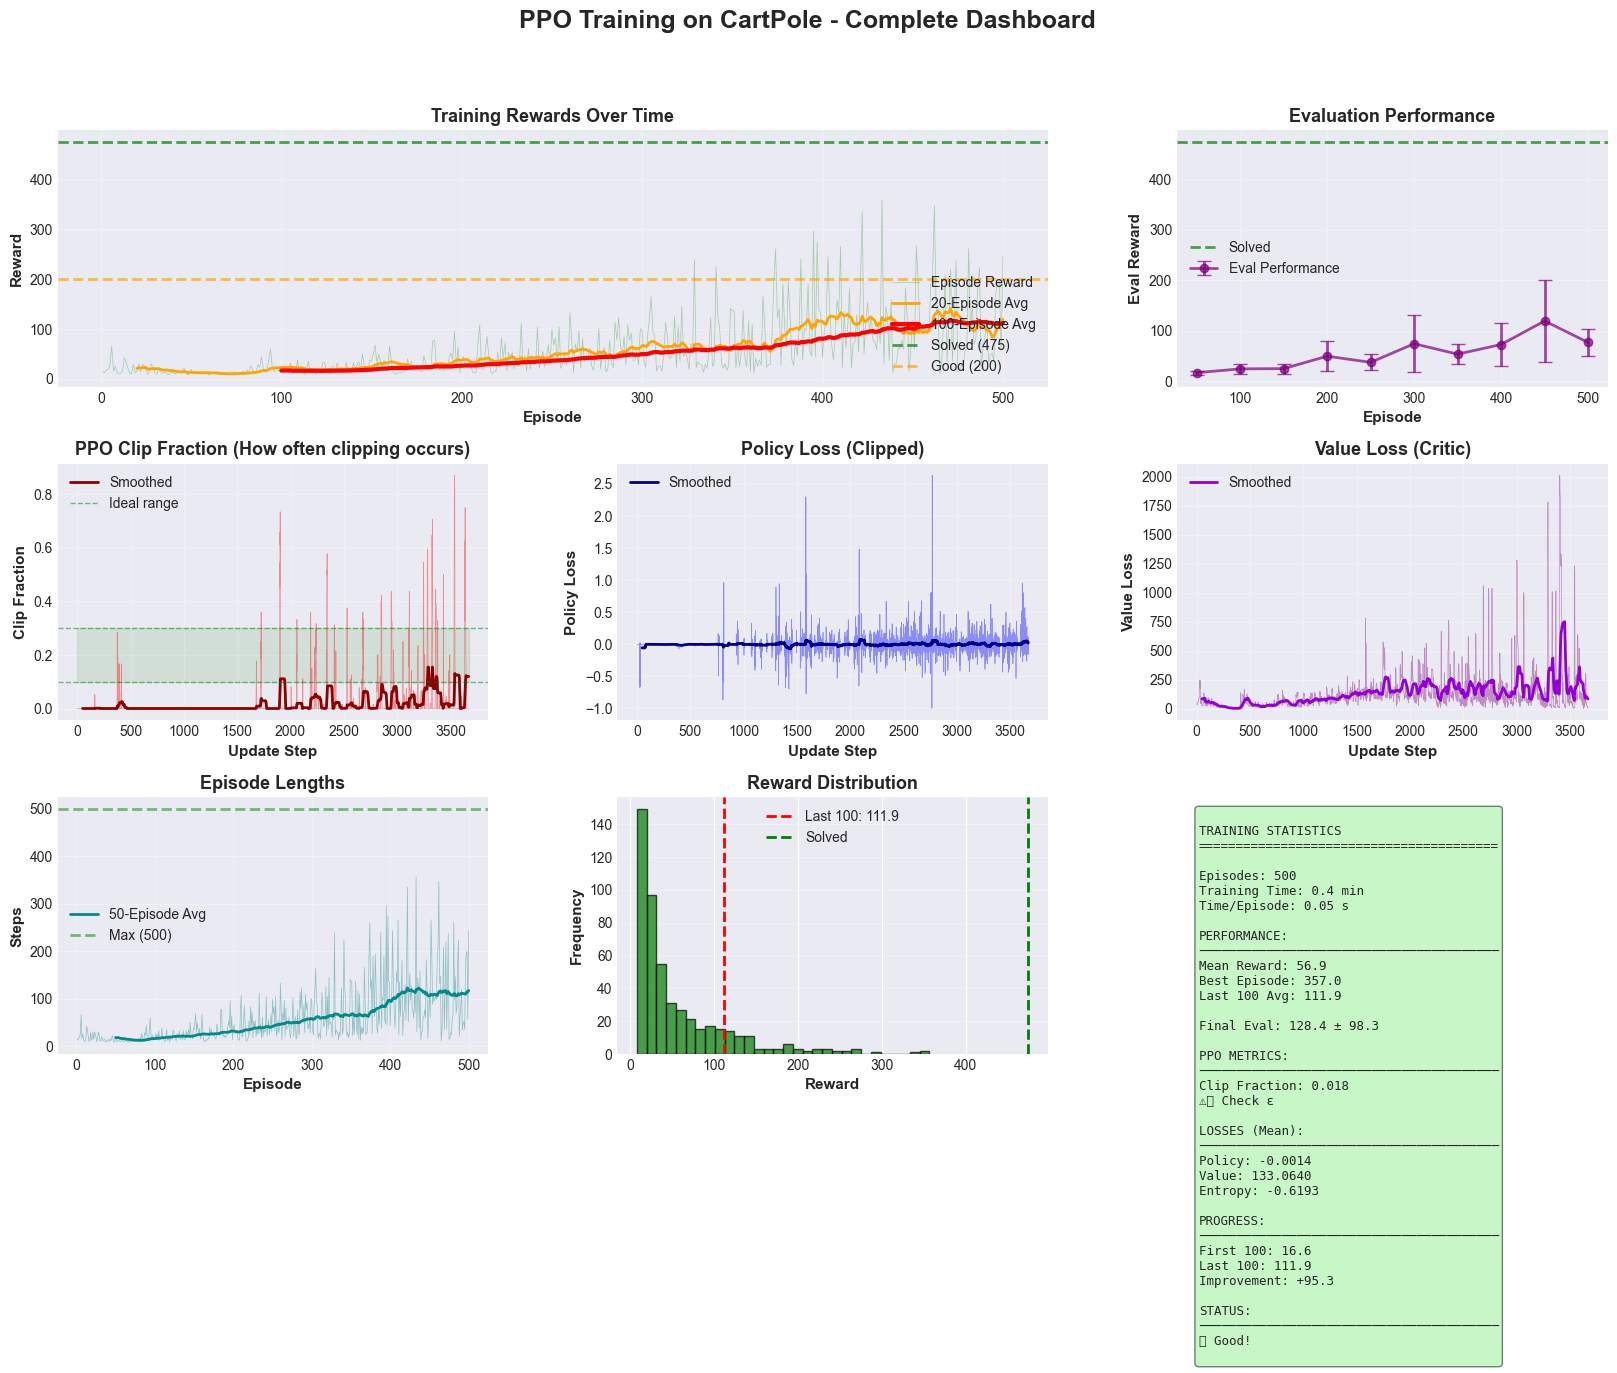


✅ Exercise 4.3 Complete!


In [21]:
# ==================================================
# EXERCISE 4.3: PPO TRAINING VISUALIZATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.3: Training Visualization Dashboard")
print("=" * 80)

print("\n📊 Creating PPO Training Dashboard:")
print("=" * 80)

# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
fig.suptitle('PPO Training on CartPole - Complete Dashboard', fontsize=18, fontweight='bold')

# 1. Episode Rewards
ax1 = fig.add_subplot(gs[0, :2])
episodes = range(1, len(episode_rewards) + 1)

# Raw rewards
ax1.plot(episodes, episode_rewards, alpha=0.3, color='green', linewidth=0.5, label='Episode Reward')

# Moving averages
if len(episode_rewards) >= 20:
    ma_20 = pd.Series(episode_rewards).rolling(window=20).mean()
    ax1.plot(episodes, ma_20, color='orange', linewidth=2, label='20-Episode Avg')

if len(episode_rewards) >= 100:
    ma_100 = pd.Series(episode_rewards).rolling(window=100).mean()
    ax1.plot(episodes, ma_100, color='red', linewidth=3, label='100-Episode Avg')

# Reference lines
ax1.axhline(475, color='green', linestyle='--', linewidth=2, label='Solved (475)', alpha=0.7)
ax1.axhline(200, color='orange', linestyle='--', linewidth=2, label='Good (200)', alpha=0.7)

ax1.set_xlabel('Episode', fontsize=11, fontweight='bold')
ax1.set_ylabel('Reward', fontsize=11, fontweight='bold')
ax1.set_title('Training Rewards Over Time', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# 2. Evaluation Performance
ax2 = fig.add_subplot(gs[0, 2])
ax2.errorbar(eval_episodes_list, eval_rewards, yerr=eval_stds,
            fmt='o-', linewidth=2, markersize=6, capsize=5,
            color='purple', alpha=0.7, label='Eval Performance')
ax2.axhline(475, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Solved')
ax2.set_xlabel('Episode', fontsize=11, fontweight='bold')
ax2.set_ylabel('Eval Reward', fontsize=11, fontweight='bold')
ax2.set_title('Evaluation Performance', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Clip Fraction (PPO-specific!)
ax3 = fig.add_subplot(gs[1, 0])
update_steps = range(1, len(clip_fractions) + 1)
ax3.plot(update_steps, clip_fractions, alpha=0.4, color='red', linewidth=0.5)

if len(clip_fractions) >= 50:
    clip_smooth = pd.Series(clip_fractions).rolling(window=50).mean()
    ax3.plot(update_steps, clip_smooth, color='darkred', linewidth=2, label='Smoothed')

ax3.axhline(0.1, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Ideal range')
ax3.axhline(0.3, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax3.fill_between([0, len(clip_fractions)], 0.1, 0.3, alpha=0.1, color='green')

ax3.set_xlabel('Update Step', fontsize=11, fontweight='bold')
ax3.set_ylabel('Clip Fraction', fontsize=11, fontweight='bold')
ax3.set_title('PPO Clip Fraction (How often clipping occurs)', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Policy Loss
ax4 = fig.add_subplot(gs[1, 1])
loss_steps = range(1, len(policy_losses) + 1)
ax4.plot(loss_steps, policy_losses, alpha=0.4, color='blue', linewidth=0.5)

if len(policy_losses) >= 50:
    loss_smooth = pd.Series(policy_losses).rolling(window=50).mean()
    ax4.plot(loss_steps, loss_smooth, color='darkblue', linewidth=2, label='Smoothed')

ax4.set_xlabel('Update Step', fontsize=11, fontweight='bold')
ax4.set_ylabel('Policy Loss', fontsize=11, fontweight='bold')
ax4.set_title('Policy Loss (Clipped)', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Value Loss
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(loss_steps, value_losses, alpha=0.4, color='purple', linewidth=0.5)

if len(value_losses) >= 50:
    value_smooth = pd.Series(value_losses).rolling(window=50).mean()
    ax5.plot(loss_steps, value_smooth, color='darkviolet', linewidth=2, label='Smoothed')

ax5.set_xlabel('Update Step', fontsize=11, fontweight='bold')
ax5.set_ylabel('Value Loss', fontsize=11, fontweight='bold')
ax5.set_title('Value Loss (Critic)', fontsize=13, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Episode Lengths
ax6 = fig.add_subplot(gs[2, 0])
ax6.plot(episodes, episode_lengths, alpha=0.4, color='teal', linewidth=0.5)

if len(episode_lengths) >= 50:
    len_smooth = pd.Series(episode_lengths).rolling(window=50).mean()
    ax6.plot(episodes, len_smooth, color='darkcyan', linewidth=2, label='50-Episode Avg')

ax6.axhline(500, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Max (500)')
ax6.set_xlabel('Episode', fontsize=11, fontweight='bold')
ax6.set_ylabel('Steps', fontsize=11, fontweight='bold')
ax6.set_title('Episode Lengths', fontsize=13, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Reward Distribution
ax7 = fig.add_subplot(gs[2, 1])
ax7.hist(episode_rewards, bins=30, color='green', alpha=0.7, edgecolor='black')
ax7.axvline(last_100_mean, color='red', linestyle='--', linewidth=2,
           label=f'Last 100: {last_100_mean:.1f}')
ax7.axvline(475, color='green', linestyle='--', linewidth=2, label='Solved')
ax7.set_xlabel('Reward', fontsize=11, fontweight='bold')
ax7.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax7.set_title('Reward Distribution', fontsize=13, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

# 8. Statistics Summary
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

stats_text = f"""
TRAINING STATISTICS
{'='*40}

Episodes: {len(episode_rewards)}
Training Time: {training_time/60:.1f} min
Time/Episode: {training_time/len(episode_rewards):.2f} s

PERFORMANCE:
{'─'*40}
Mean Reward: {mean_reward:.1f}
Best Episode: {max_reward:.1f}
Last 100 Avg: {last_100_mean:.1f}

Final Eval: {final_mean:.1f} ± {final_std:.1f}

PPO METRICS:
{'─'*40}
Clip Fraction: {mean_clip_fraction:.3f}
{'✓ Good range!' if 0.1 <= mean_clip_fraction <= 0.3 else '⚠️ Check ε'}

LOSSES (Mean):
{'─'*40}
Policy: {np.mean(policy_losses):.4f}
Value: {np.mean(value_losses):.4f}
Entropy: {np.mean(entropy_losses):.4f}

PROGRESS:
{'─'*40}
First 100: {first_100_mean:.1f}
Last 100: {last_100_mean:.1f}
Improvement: +{improvement:.1f}

STATUS:
{'─'*40}
{'✅ SOLVED!' if final_mean >= 475 else '🎯 Excellent!' if final_mean >= 400 else '📈 Good!'}
"""

ax8.text(0.05, 0.95, stats_text, transform=ax8.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('results/ppo/ppo_cartpole_training.png', dpi=300, bbox_inches='tight')
print("✅ Training dashboard saved!")
plt.show()

print("\n✅ Exercise 4.3 Complete!")
print("=" * 80)